# Reconstruction and inference of gene co-expression networks in pancreatic ductal adenocarcinoma using an *ensemble* correlation approach

### Bachelor's Thesis (Trabajo de Fin de Grado)

**Author:** Lola Barrios Naranjo
**Dataset:** GSE28735 — *Gene Expression Omnibus* (NCBI)
**Platform:** Affymetrix Human Gene 1.0 ST Array (GPL6244)
**External validation:** BioGRID (release 5.0.255) and TCGA-PAAD (UCSC Xena)

---

## Abstract

Pancreatic ductal adenocarcinoma (PDAC) is one of the deadliest neoplasms, motivating the search for new biomarkers and therapeutic targets through systems biology approaches. This work develops a complete, reproducible and computationally robust pipeline for (i) the identification of differentially expressed genes (DEGs) between tumor and adjacent non-tumor tissue from the public dataset GSE28735 using a paired moderated t-test in the spirit of limma (Smyth, 2004), (ii) the inference of a condition-specific gene co-expression network using an *ensemble* scheme based on majority voting across three correlation coefficients (Pearson, Spearman, Kendall), (iii) the validation of the biological coherence of the resulting network (*Gene Network Coherence*, GNC) against the curated BioGRID database with permutation testing, (iv) the assessment of the prognostic value of the most topologically central genes (*hub genes*) via survival analysis (Kaplan-Meier and Cox regression) on the independent TCGA-PAAD cohort, and (v) the verification of pipeline robustness via a biological sanity check and rigorous evaluation of the *scale-free* property of the network using maximum-likelihood estimation (Clauset et al., 2009). The final outputs are Cytoscape-compatible files for visualization and topological analysis of the tumor-specific phenotype network.

## Notebook structure

1. Environment setup and reproducibility
2. Library imports
3. Data acquisition and inspection (GSE28735)
4. Quality control and exploratory analysis
5. Probe annotation and gene-symbol collapse
6. Differential expression analysis (paired moderated t-test)
7. Co-expression network inference: *ensemble* approach
8. Threshold selection and Cytoscape export
9. Biological validation against BioGRID (GNC)
10. Tumor-phenotype-specific differential network
11. Node-attribute generation for Cytoscape
12. Survival analysis (Kaplan-Meier and Cox)
13. Internal validation and robustness (sanity check, scale-free, GNC permutation)
14. Cross-validation of DEA with limma in R (methodological appendix)
15. Conclusions
16. References

## 1. Environment setup and reproducibility

A global random seed is fixed and all paths and analysis hyperparameters are centralized in a single block to guarantee strict reproducibility of the pipeline. Any modification of thresholds or paths must be made exclusively in this block.

In [ ]:
# Silent installation of specific dependencies (skip if already installed)
!pip install -q GEOparse gseapy lifelines networkx powerlaw

In [ ]:
# --- GLOBAL ANALYSIS PARAMETERS ---
import os
import random
import numpy as np

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Study identifiers
GEO_ID         = "GSE28735"
PLATFORM_COL   = "gene_assignment"   # GPL column containing the annotation
HUMAN_TAX_ID   = "9606"              # Homo sapiens (NCBI Taxonomy)

# Differential expression analysis thresholds
FDR_THRESHOLD          = 0.05    # False Discovery Rate (Benjamini-Hochberg)
LOGFC_STRICT           = 1.0     # 2-fold change — canonical, high-specificity criterion
LOGFC_PERMISSIVE       = 0.585   # 1.5-fold change — captures DEGs with moderate effects
LOGFC_THRESHOLD        = LOGFC_PERMISSIVE  # Threshold chosen for downstream analysis

# Ensemble network inference thresholds
CORR_THRESHOLDS   = [0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
ENSEMBLE_VOTES    = 2      # Minimum votes (out of 3) to accept an edge
INITIAL_THRESHOLD = 0.75   # First choice based on edges-vs-threshold curve
FINAL_THRESHOLD   = 0.80   # Final threshold after refinement via GNC vs threshold

# Hub and survival analysis
TOP_N_HUBS        = 20     # Most central hubs for the prognostic analysis

# Input/output paths
DATA_DIR     = "./"
OUTPUT_DIR   = "./results"
BIOGRID_PATH = "/content/drive/MyDrive/tfg/BIOGRID-ALL-5.0.255.tab.txt"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"Global seed set to: {SEED}")

Output directory: /content/results
Global seed set to: 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Library imports

Imports are grouped by functional domain (data handling, statistics, visualization, networks, bioinformatics). At the end of the notebook the version of every package is printed for full traceability of the environment.

In [ ]:
# --- DATA HANDLING & SYSTEM ---
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# --- BIOINFORMATICS ---
import GEOparse

# --- STATISTICS ---
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- UNSUPERVISED LEARNING (quality control) ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- NETWORKS ---
import networkx as nx

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titleweight"] = "bold"

## 3. Data acquisition and inspection (GSE28735)

The **GSE28735** dataset (Zhang G. *et al.*, 2012) contains gene expression profiles of 45 matched pairs of pancreatic tumor tissue and adjacent non-tumor tissue, generated on the Affymetrix Human Gene 1.0 ST Array platform. The data is downloaded directly from the NCBI GEO repository via the `GEOparse` library.

In [ ]:
# --- DATASET DOWNLOAD ---
gse = GEOparse.get_GEO(geo=GEO_ID, destdir=DATA_DIR, silent=True)

# Expression matrix (rows = probes, columns = samples)
df_exp = gse.pivot_samples("VALUE")

print(f"Dataset: {GEO_ID}")
print(f"Number of probes : {df_exp.shape[0]:>6}")
print(f"Number of samples: {df_exp.shape[1]:>6}")

Dataset: GSE28735
Number of probes :  28869
Number of samples:     90


In [ ]:
# --- INITIAL INSPECTION ---
print("\n>>> Expression matrix head (first 5 probes / 5 samples):")
display(df_exp.iloc[:5, :5])

# Missing values check
total_nans = int(df_exp.isnull().sum().sum())
print(f"\nNaN values in the matrix: {total_nans}")

# Platform info
gpl_id = list(gse.gpls.keys())[0]
print(f"Microarray platform: {gpl_id}")

# Sample metadata example
example_gsm = list(gse.gsms.keys())[0]
print(f"\nMetadata example for {example_gsm}:")
print(" - title       :", gse.gsms[example_gsm].metadata.get("title", ["NA"])[0])
print(" - source_name :", gse.gsms[example_gsm].metadata.get("source_name_ch1", ["NA"])[0])


>>> Expression matrix head (first 5 probes / 5 samples):


name,GSM711904,GSM711905,GSM711906,GSM711907,GSM711908
ID_REF,,,,,
7896736,3.30105,4.31783,2.98749,3.54810,2.97383
7896738,1.85066,1.84630,2.14159,1.83839,2.37636
7896740,2.02519,2.11336,2.15384,1.88753,2.22671
7896742,4.47212,5.26114,4.45806,5.72147,5.18768
7896744,4.33654,4.48297,4.44503,4.62130,4.09481



NaN values in the matrix: 0
Microarray platform: GPL6244

Metadata example for GSM711904:
 - title       : human pancreatic tumor tissue, patient sample 1
 - source_name : tumor tissue, patient 1


## 4. Quality control and exploratory analysis

Before starting any statistical analysis, it is essential to verify (i) that the intensity distributions of each sample are comparable, indicating proper normalization, and (ii) that there is a natural separation between biological classes in principal-component space, justifying the subsequent search for DEGs.

In [ ]:
# --- GROUP DEFINITION FROM EACH SAMPLE TITLE ---
samples_info = []
for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [""])[0].lower()
    condition = "Normal" if "nontumor" in title else "Tumor"
    samples_info.append({"SampleID": gsm_name, "Condition": condition})

df_targets = pd.DataFrame(samples_info).set_index("SampleID")
print("Sample distribution by condition:")
print(df_targets["Condition"].value_counts().to_string())

Sample distribution by condition:
Condition
Tumor     45
Normal    45


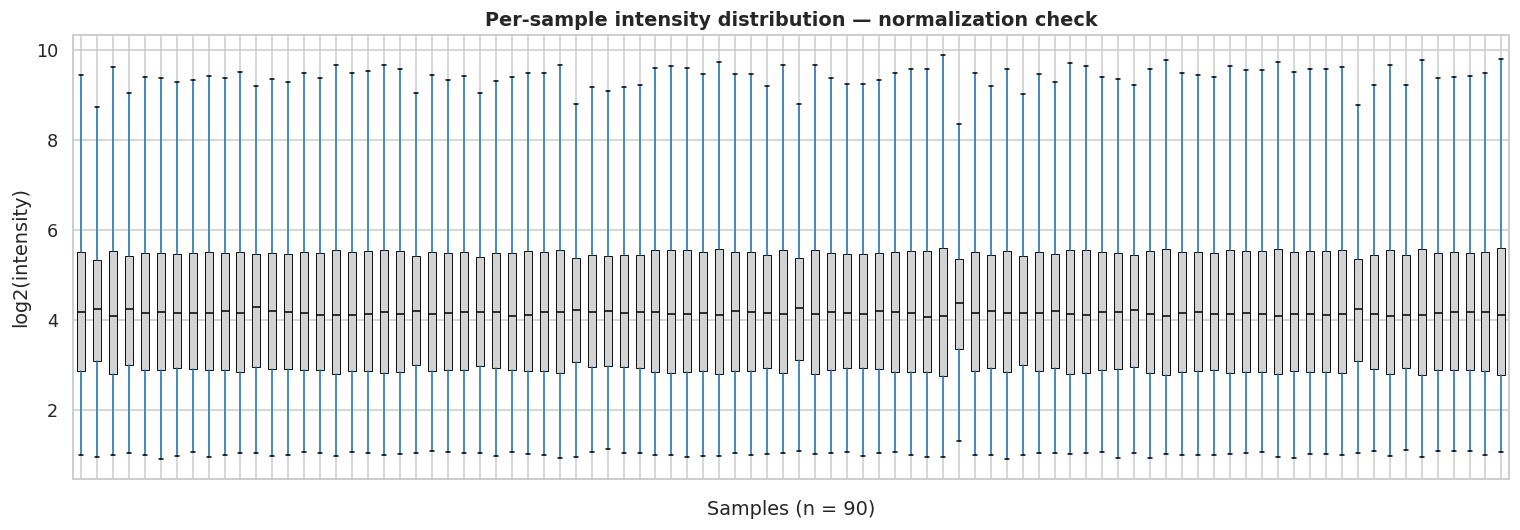

In [ ]:
# --- SAMPLE-INTENSITY BOXPLOT (normalization sanity check) ---
fig, ax = plt.subplots(figsize=(14, 5))
df_exp.boxplot(
    ax=ax, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="lightgrey", linewidth=0.6),
    medianprops=dict(color="black", linewidth=1.0),
)
ax.set_xticklabels([])
ax.set_xlabel(f"Samples (n = {df_exp.shape[1]})")
ax.set_ylabel("log2(intensity)")
ax.set_title("Per-sample intensity distribution — normalization check")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "QC_boxplot_intensities.png"), bbox_inches="tight")
plt.show()

In [ ]:
# --- CÁLCULO DE RANGOS DE INTENSIDAD ---
# Calculamos el mínimo, el máximo y el rango intercuartílico (IQR) global
global_min = df_exp.min().min()
global_max = df_exp.max().max()
global_median_range = (df_exp.median().min(), df_exp.median().max())

print(f"--- Resumen de Intensidades (log2) ---")
print(f"Rango absoluto: [{global_min:.2f}, {global_max:.2f}]")
print(f"Las medianas de los samples oscilan entre: {global_median_range[0]:.2f} y {global_median_range[1]:.2f}")

--- Resumen de Intensidades (log2) ---
Rango absoluto: [0.90, 12.99]
Las medianas de los samples oscilan entre: 4.06 y 4.37


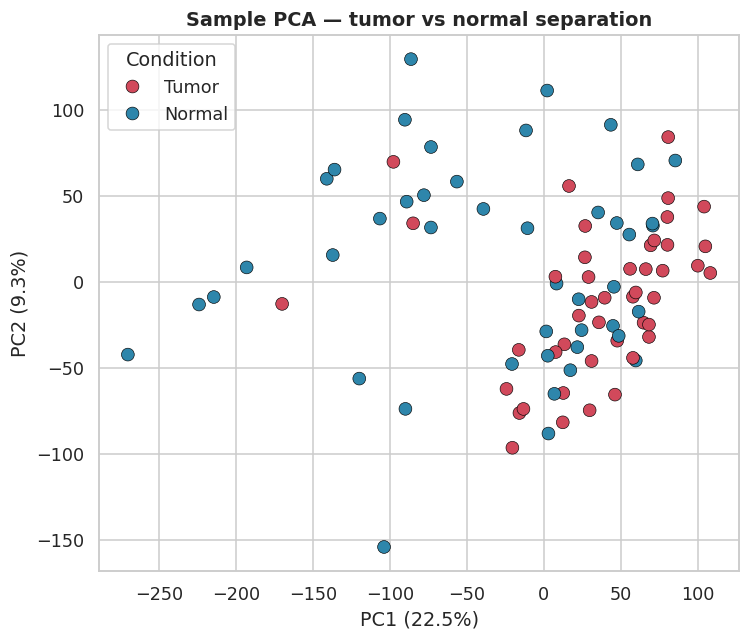

In [ ]:
# --- PRINCIPAL COMPONENT ANALYSIS (PCA) ---
# PCA is computed at the sample level: each sample is a point in probe space.
exp_matrix = df_exp.dropna(axis=0).T              # rows = samples
exp_scaled = StandardScaler().fit_transform(exp_matrix)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(exp_scaled)

df_pca = pd.DataFrame(coords, columns=["PC1", "PC2"], index=exp_matrix.index)
df_pca["Condition"] = df_targets.loc[df_pca.index, "Condition"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue="Condition",
    palette={"Tumor": "#d1495b", "Normal": "#2e86ab"},
    s=70, edgecolor="black", linewidth=0.4, ax=ax,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Sample PCA — tumor vs normal separation")
ax.legend(title="Condition", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "QC_PCA_samples.png"), bbox_inches="tight")
plt.show()

## 5. Probe annotation and gene-symbol collapse

The expression matrix is indexed by Affymetrix probe identifiers. To make the analysis biologically interpretable and compatible with BioGRID, probes are translated to official gene symbols (HGNC). When several probes map to the same gene they are collapsed by averaging intensities, the standard criterion for one-color microarrays.

In [ ]:
# --- BUILDING THE PROBE -> GENE SYMBOL DICTIONARY ---
gpl = gse.gpls[gpl_id]

def extract_symbol(annotation_str):
    # Extract the gene symbol from an Affymetrix annotation string.
    # Typical format: 'Accession // Symbol // Title // ...'.
    # Returns empty string if no valid symbol is present.
    if not isinstance(annotation_str, str) or "//" not in annotation_str:
        return ""
    parts = [p.strip() for p in annotation_str.split("//")]
    symbol = parts[1] if len(parts) > 1 else ""
    return "" if symbol in {"---", "", "NA"} else symbol

mapping = (
    gpl.table[["ID", PLATFORM_COL]]
       .assign(GeneSymbol=lambda d: d[PLATFORM_COL].map(extract_symbol))
       .query("GeneSymbol != ''")
       .set_index("ID")["GeneSymbol"]
       .to_dict()
)
print(f"Probes annotated to a valid gene symbol: {len(mapping):,}")

Probes annotated to a valid gene symbol: 25,293


In [ ]:
# --- GENE-LEVEL COLLAPSE (average across probes per gene) ---
df_mapped = df_exp.loc[df_exp.index.isin(mapping)].copy()
df_mapped["GeneSymbol"] = df_mapped.index.map(mapping)

df_final = df_mapped.groupby("GeneSymbol").mean()
df_final.index.name = "GeneSymbol"

print(f"Matrix after annotation : {df_mapped.shape}  (probes x samples)")
print(f"Matrix after collapse   : {df_final.shape}  (unique genes x samples)")
display(df_final.head())

# Reference gene list (useful for downstream enrichment analyses)
ref_path = os.path.join(OUTPUT_DIR, "reference_GSE28735.txt")
df_final.index.to_series().to_csv(ref_path, index=False, header=False)
print(f"Reference list exported to: {ref_path}")

Matrix after annotation : (25293, 91)  (probes x samples)
Matrix after collapse   : (23307, 90)  (unique genes x samples)


name,GSM711904,GSM711905,GSM711906,GSM711907,GSM711908,GSM711909,GSM711910,GSM711911,GSM711912,GSM711913,...,GSM711984,GSM711985,GSM711986,GSM711987,GSM711988,GSM711989,GSM711990,GSM711991,GSM711992,GSM711993
GeneSymbol,,,,,,,,,,,,,,,,,,,,,
A1BG,4.48602,4.35176,3.80774,4.45414,4.44275,4.51644,4.08091,4.61910,4.24729,4.52622,...,4.50350,4.36927,3.99810,3.91582,3.97619,4.43640,4.35029,4.02852,4.28604,4.13976
A1CF,3.66719,4.99803,3.09038,3.87257,3.30879,2.82807,2.84618,3.71973,3.30672,5.65339,...,4.96462,5.09651,4.01222,5.34478,3.24854,5.31381,3.22290,3.75284,4.18054,4.54581
A2M,9.64680,7.59898,8.70488,8.84534,7.76990,10.40330,10.02350,9.57773,9.11030,9.35105,...,8.33680,8.94466,8.58127,8.14499,9.91629,9.39237,10.20030,10.10220,9.55357,10.08100
A2ML1,2.80187,3.35182,2.87407,2.92427,3.96296,3.05066,2.96377,2.96309,3.32235,2.90203,...,3.35934,2.89069,5.82696,2.82627,2.98321,3.06382,2.93297,2.78541,5.05342,2.59977
A3GALT2,2.84598,3.54208,2.39143,2.56212,2.54507,2.88230,2.70443,2.77548,2.52317,2.75215,...,2.99998,2.72139,2.28205,2.95503,2.29138,3.07413,2.61720,2.60076,2.40253,2.48684


Reference list exported to: ./results/reference_GSE28735.txt


## 6. Differential expression analysis (DEA)

The GSE28735 dataset follows a **paired design** in which each patient contributes two samples (tumor and adjacent non-tumor tissue). To respect this design and maximize statistical power, a **paired moderated t-test** is applied following Smyth (2004): each gene-specific variance is updated towards a prior variance `s²₀` (geometric mean of observed variances) with prior degrees of freedom `d₀ = 4`. The moderated statistic is computed as:

$$t_g^{\text{mod}} = \frac{\bar{d}_g}{\sqrt{s_g^{2,\text{mod}} / n}}, \qquad s_g^{2,\text{mod}} = \frac{d_0\,s_0^{2} + d_g\,s_g^{2}}{d_0 + d_g}$$

P-values are adjusted using the Benjamini-Hochberg method to control the False Discovery Rate (FDR). A gene is considered **differentially expressed** when it simultaneously satisfies:

$$|\log_2 \text{FC}| > \text{threshold} \quad \text{and} \quad \text{FDR} < 0.05$$

This formulation is methodologically equivalent (in its Bayesian essence) to the implementation provided by the R `limma` library, considered the gold standard for microarray analysis. The DEGs are evaluated under **two thresholds in parallel** for downstream comparison:
- **Strict** (|logFC| > 1.0, 2-fold change): high specificity, conservative.
- **Permissive** (|logFC| > 0.585, 1.5-fold change): captures genes with moderate but biologically relevant effects.

In [ ]:
# --- SAMPLE ALIGNMENT AND GROUP SEPARATION ---
common_samples = df_final.columns.intersection(df_targets.index)
data    = df_final[common_samples]
targets = df_targets.loc[common_samples]

tumor_samples  = targets.index[targets["Condition"] == "Tumor"]
normal_samples = targets.index[targets["Condition"] == "Normal"]

tumor_data  = data[tumor_samples]
normal_data = data[normal_samples]

print(f"Comparison: {len(tumor_samples)} tumor vs {len(normal_samples)} normal controls.")

Comparison: 45 tumor vs 45 normal controls.


In [ ]:
# --- GENE-WISE STATISTICS: PAIRED MODERATED T-TEST (limma-style, Smyth 2004) ---
import re
from scipy.stats import t as t_dist

# 1. Pair tumor-normal samples by patient
def get_patient_id(gsm_name):
    """Extract the numeric patient identifier from the sample title."""
    title = gse.gsms[gsm_name].metadata.get("title", [""])[0]
    m = re.search(r"(\d+)$", title)
    return m.group(1) if m else None

tumor_pid  = {get_patient_id(s): s for s in tumor_samples}
normal_pid = {get_patient_id(s): s for s in normal_samples}
pairs = [(tumor_pid[p], normal_pid[p]) for p in tumor_pid if p in normal_pid]
print(f"Matched tumor-normal pairs: {len(pairs)}")

# 2. Per-patient difference matrix: rows = genes, columns = pairs
tumor_arr  = data[[t for t, _ in pairs]].values
normal_arr = data[[n for _, n in pairs]].values
diffs = tumor_arr - normal_arr
n_pairs = diffs.shape[1]

# 3. Per-gene statistics (logFC = mean of differences)
logFC = diffs.mean(axis=1)
var_g = diffs.var(axis=1, ddof=1)
df_g  = n_pairs - 1

# 4. Bayesian variance shrinkage (Empirical Bayes, simplified Smyth 2004)
mask_pos = var_g > 0
s2_0 = np.exp(np.median(np.log(var_g[mask_pos])))   # prior: geometric mean of variances
df_0 = 4                                             # prior degrees of freedom (standard empirical value)

var_mod  = (df_0 * s2_0 + df_g * var_g) / (df_0 + df_g)
se_mod   = np.sqrt(var_mod / n_pairs)
t_mod    = logFC / se_mod
df_total = df_0 + df_g
p_val    = 2 * t_dist.sf(np.abs(t_mod), df_total)

# 5. Results DataFrame (statistics common to both thresholds)
results = pd.DataFrame({
    "logFC"      : logFC,
    "P_Value"    : p_val,
    "t_moderated": t_mod,
    "Mean_Tumor" : tumor_arr.mean(axis=1),
    "Mean_Normal": normal_arr.mean(axis=1),
}, index=data.index)

# 6. Multiple-testing correction (Benjamini-Hochberg)
_, pvals_corrected, _, _ = multipletests(results["P_Value"].fillna(1), method="fdr_bh")
results["adj_P_Val"] = pvals_corrected

# 7. DUAL CLASSIFICATION: strict (|logFC|>1.0) vs permissive (|logFC|>0.585)
def classify(df, logfc_thr, fdr_thr):
    cls = pd.Series("NO", index=df.index)
    cls[(df["logFC"] >  logfc_thr) & (df["adj_P_Val"] < fdr_thr)] = "UP"
    cls[(df["logFC"] < -logfc_thr) & (df["adj_P_Val"] < fdr_thr)] = "DOWN"
    return cls

results["DiffExpressed_strict"]     = classify(results, LOGFC_STRICT,     FDR_THRESHOLD)
results["DiffExpressed_permissive"] = classify(results, LOGFC_PERMISSIVE, FDR_THRESHOLD)

# Compatibility with the rest of the notebook (uses the threshold chosen in parameters)
results["DiffExpressed"] = classify(results, LOGFC_THRESHOLD, FDR_THRESHOLD)

print("\nComparative DEA summary (paired moderated t-test):")
print(f"\n  STRICT threshold  (|logFC|>{LOGFC_STRICT}, FDR<{FDR_THRESHOLD}):")
print(results["DiffExpressed_strict"].value_counts().to_string())
print(f"\n  PERMISSIVE threshold (|logFC|>{LOGFC_PERMISSIVE}, FDR<{FDR_THRESHOLD}):")
print(results["DiffExpressed_permissive"].value_counts().to_string())
print(f"\n  CHOSEN threshold for downstream: |logFC|>{LOGFC_THRESHOLD}")
print(results["DiffExpressed"].value_counts().to_string())

Matched tumor-normal pairs: 45

Comparative DEA summary (paired moderated t-test):

  STRICT threshold  (|logFC|>1.0, FDR<0.05):
DiffExpressed_strict
NO      22892
UP        254
DOWN      161

  PERMISSIVE threshold (|logFC|>0.585, FDR<0.05):
DiffExpressed_permissive
NO      21952
UP        825
DOWN      530

  CHOSEN threshold for downstream: |logFC|>0.585
DiffExpressed
NO      21952
UP        825
DOWN      530


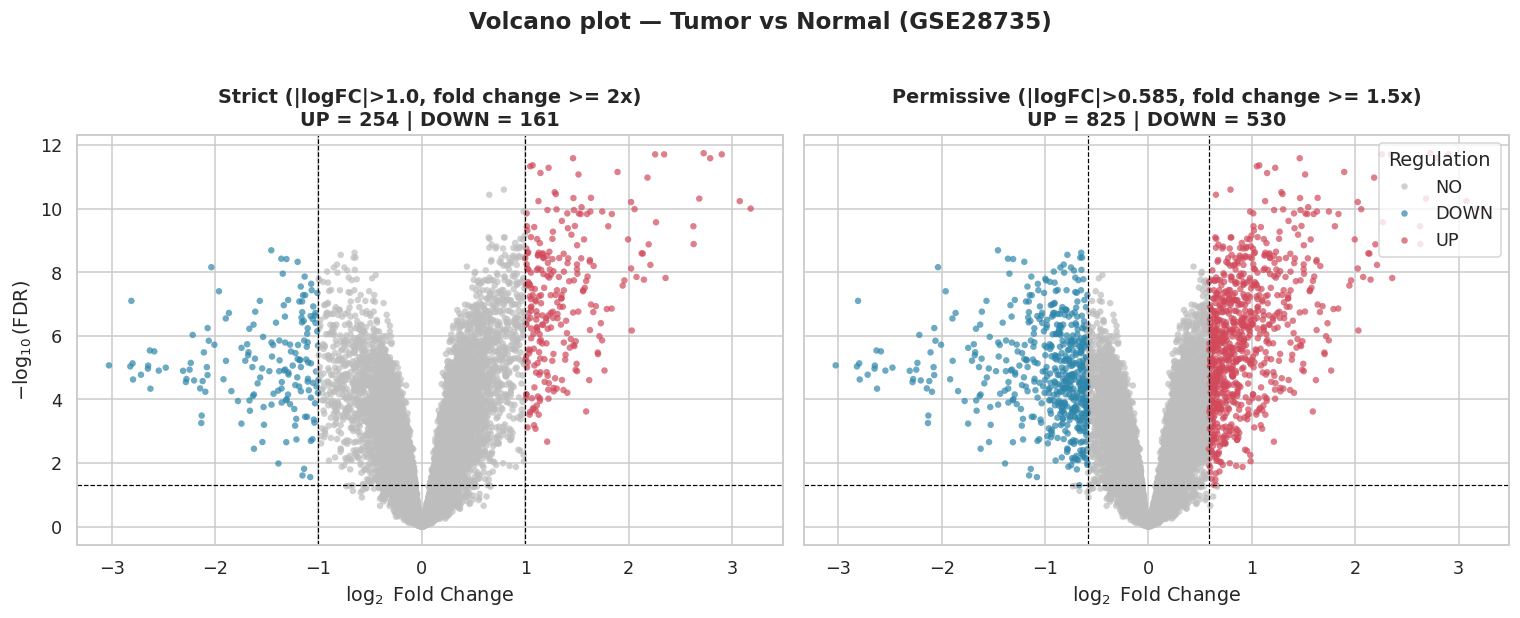


DEGs selected for downstream (|logFC|>0.585): 1355


In [ ]:
# --- COMPARATIVE VOLCANO PLOT (strict vs permissive) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
palette = {"NO": "#bdbdbd", "UP": "#d1495b", "DOWN": "#2e86ab"}

for ax, col, thr, title in [
    (axes[0], "DiffExpressed_strict",     LOGFC_STRICT,     f"Strict (|logFC|>{LOGFC_STRICT}, fold change >= 2x)"),
    (axes[1], "DiffExpressed_permissive", LOGFC_PERMISSIVE, f"Permissive (|logFC|>{LOGFC_PERMISSIVE}, fold change >= 1.5x)"),
]:
    sns.scatterplot(
        data=results, x="logFC", y=-np.log10(results["adj_P_Val"]),
        hue=col, palette=palette,
        alpha=0.7, s=18, edgecolor="none", ax=ax, legend=(ax is axes[1]),
    )
    ax.axvline( thr, color="black", linestyle="--", linewidth=0.8)
    ax.axvline(-thr, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-np.log10(FDR_THRESHOLD), color="black", linestyle="--", linewidth=0.8)
    n_up   = (results[col] == "UP").sum()
    n_down = (results[col] == "DOWN").sum()
    ax.set_title(f"{title}\nUP = {n_up} | DOWN = {n_down}")
    ax.set_xlabel(r"$\log_2$ Fold Change")
    ax.set_ylabel(r"$-\log_{10}$(FDR)" if ax is axes[0] else "")

axes[1].legend(title="Regulation", loc="upper right")
plt.suptitle(f"Volcano plot — Tumor vs Normal ({GEO_ID})", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "volcano_plot_comparative.png"), bbox_inches="tight")
plt.show()

# Final DEG selection for network construction (threshold chosen in parameters)
df_degs_final = results[results["DiffExpressed"] != "NO"].copy()
print(f"\nDEGs selected for downstream (|logFC|>{LOGFC_THRESHOLD}): {len(df_degs_final)}")

In [ ]:
# --- COMPARISON: PDAC CANONICAL GENES UNDER BOTH THRESHOLDS ---
# This cell evaluates which threshold best captures documented PDAC biology.
# The list is drawn from the reference set in Zhang et al. 2012 plus other key markers.
canonical_PDAC_genes = [
    # Genetic drivers (typically altered by mutation, not expression)
    "KRAS", "TP53", "CDKN2A", "SMAD4",
    # Frequently altered genes
    "MYC", "BRCA2",
    # Stromal and invasiveness markers
    "MUC1", "S100A4", "S100P", "MMP7", "LOXL2",
    # Ductal markers and clinical biomarkers
    "KRT19", "REG1A", "CEACAM5", "CEACAM6",
    # Genes highlighted in the original paper (Zhang 2012)
    "DPEP1", "TPX2", "PRR11", "DCBLD2", "ANLN",
    "CDO1", "C7", "ALDH1A1", "NR3C2",
]

comp_rows = []
for col, label in [("DiffExpressed_strict",     f"Strict (|logFC|>{LOGFC_STRICT})"),
                    ("DiffExpressed_permissive", f"Permissive (|logFC|>{LOGFC_PERMISSIVE})")]:
    degs_here = results[results[col] != "NO"]
    found = sorted(set(canonical_PDAC_genes) & set(degs_here.index))
    missing = sorted(set(canonical_PDAC_genes) - set(degs_here.index))
    comp_rows.append({
        "Threshold"   : label,
        "Total DEGs"  : len(degs_here),
        "Canonical OK": f"{len(found)}/{len(canonical_PDAC_genes)}",
        "Found"       : ", ".join(found),
        "Missing"     : ", ".join(missing),
    })

df_comp = pd.DataFrame(comp_rows)
print("\n=== COMPARATIVE COVERAGE OF PDAC CANONICAL GENES ===\n")
for _, r in df_comp.iterrows():
    print(f"-- {r['Threshold']} --")
    print(f"   Total DEGs        : {r['Total DEGs']:,}")
    print(f"   Canonical coverage: {r['Canonical OK']}")
    print(f"   Detected: {r['Found']}")
    print(f"   Missing : {r['Missing']}")
    print()

# Detailed table of detected canonical genes with their behavior
detailed = sorted(set(canonical_PDAC_genes) & set(results.index))
display(results.loc[detailed, ["logFC", "adj_P_Val",
                                "DiffExpressed_strict",
                                "DiffExpressed_permissive"]]
              .sort_values("logFC", ascending=False))

print("\nInterpretive note:")
print("  Genetic drivers (KRAS, TP53, CDKN2A, SMAD4) typically do not appear even in a")
print("  well-built network: they are altered by MUTATION (not transcriptional expression).")
print("  Their absence does not indicate a pipeline failure.")


=== COMPARATIVE COVERAGE OF PDAC CANONICAL GENES ===

-- Strict (|logFC|>1.0) --
   Total DEGs        : 415
   Canonical coverage: 13/24
   Detected: ALDH1A1, ANLN, C7, CEACAM5, CEACAM6, DCBLD2, KRT19, LOXL2, MMP7, MUC1, REG1A, S100P, TPX2
   Missing : BRCA2, CDKN2A, CDO1, DPEP1, KRAS, MYC, NR3C2, PRR11, S100A4, SMAD4, TP53

-- Permissive (|logFC|>0.585) --
   Total DEGs        : 1,355
   Canonical coverage: 17/24
   Detected: ALDH1A1, ANLN, C7, CEACAM5, CEACAM6, DCBLD2, DPEP1, KRT19, LOXL2, MMP7, MUC1, MYC, NR3C2, PRR11, REG1A, S100P, TPX2
   Missing : BRCA2, CDKN2A, CDO1, KRAS, S100A4, SMAD4, TP53



,logFC,adj_P_Val,DiffExpressed_strict,DiffExpressed_permissive
GeneSymbol,,,,
CEACAM5,3.181287,9.928810e-11,UP,UP
CEACAM6,2.627122,3.577974e-10,UP,UP
KRT19,2.058020,1.037116e-10,UP,UP
ANLN,1.662017,6.360521e-09,UP,UP
LOXL2,1.238035,8.173596e-09,UP,UP
S100P,1.226079,5.198793e-12,UP,UP
MMP7,1.212934,2.121529e-03,UP,UP
MUC1,1.123698,8.035576e-05,UP,UP
TPX2,1.108897,1.686198e-07,UP,UP



Interpretive note:
  Genetic drivers (KRAS, TP53, CDKN2A, SMAD4) typically do not appear even in a
  well-built network: they are altered by MUTATION (not transcriptional expression).
  Their absence does not indicate a pipeline failure.


## 7. Co-expression network inference: *ensemble* approach

A gene network is reconstructed for each condition (tumor and normal) restricted to the DEG subset. To reduce the methodological bias inherent to any single coefficient, three gene-gene correlation matrices are computed:

- **Pearson** — parametric linear correlation.
- **Spearman** — rank-based correlation, robust to monotonic non-linearities.
- **Kendall** — concordance-based rank correlation, robust to *outliers*.

An edge is accepted when, for a threshold `t`, at least **2 out of 3** coefficients exceed `|r| ≥ t` (majority voting). This *ensemble* strategy increases the specificity of the network against false positives derived from a single method.

In [ ]:
# --- DEG-RESTRICTED EXPRESSION MATRICES ---
tumor_degs_matrix  = df_final.loc[df_degs_final.index, tumor_samples]
normal_degs_matrix = df_final.loc[df_degs_final.index, normal_samples]

print(f"Tumor matrix  (DEGs x samples): {tumor_degs_matrix.shape}")
print(f"Normal matrix (DEGs x samples): {normal_degs_matrix.shape}")

Tumor matrix  (DEGs x samples): (1355, 45)
Normal matrix (DEGs x samples): (1355, 45)


In [ ]:
def compute_correlations(expression_matrix):
    # Compute the three gene-gene correlation matrices (Pearson, Spearman, Kendall)
    # over a genes-x-samples matrix.
    df_t = expression_matrix.T   # genes -> columns, samples -> rows
    return (
        df_t.corr(method="pearson"),
        df_t.corr(method="spearman"),
        df_t.corr(method="kendall"),
    )

p_tumor,  s_tumor,  k_tumor  = compute_correlations(tumor_degs_matrix)
p_normal, s_normal, k_normal = compute_correlations(normal_degs_matrix)
print("Correlation matrices computed for both conditions.")

Correlation matrices computed for both conditions.


In [ ]:
def ensemble_voting(cp, cs, ck, threshold, min_votes=ENSEMBLE_VOTES):
    # Apply majority voting across the three correlation matrices.
    # Returns a binary adjacency matrix (0/1) without self-loops.
    mask = (cp.abs() >= threshold).astype(int) \
         + (cs.abs() >= threshold).astype(int) \
         + (ck.abs() >= threshold).astype(int)
    adj = (mask >= min_votes).astype(int)
    np.fill_diagonal(adj.values, 0)
    return adj


def count_edges(adj):
    # Number of unique edges in a symmetric adjacency matrix.
    return int(adj.values.sum() // 2)


# --- THRESHOLD SWEEP ---
print(f"{'Threshold':<12}{'Tumor edges':<16}{'Normal edges':<16}")
print("-" * 44)

network_summary = []
for u in CORR_THRESHOLDS:
    nt = count_edges(ensemble_voting(p_tumor,  s_tumor,  k_tumor,  u))
    nn = count_edges(ensemble_voting(p_normal, s_normal, k_normal, u))
    print(f"{u:<12}{nt:<16,}{nn:<16,}")
    network_summary.append({"Threshold": u, "Tumor_edges": nt, "Normal_edges": nn})

df_summary = pd.DataFrame(network_summary)

Threshold   Tumor edges     Normal edges    
--------------------------------------------
0.6         42,313          165,496         
0.7         12,162          84,799          
0.75        6,137           51,894          
0.8         2,980           26,988          
0.85        1,216           10,341          
0.9         415             2,339           


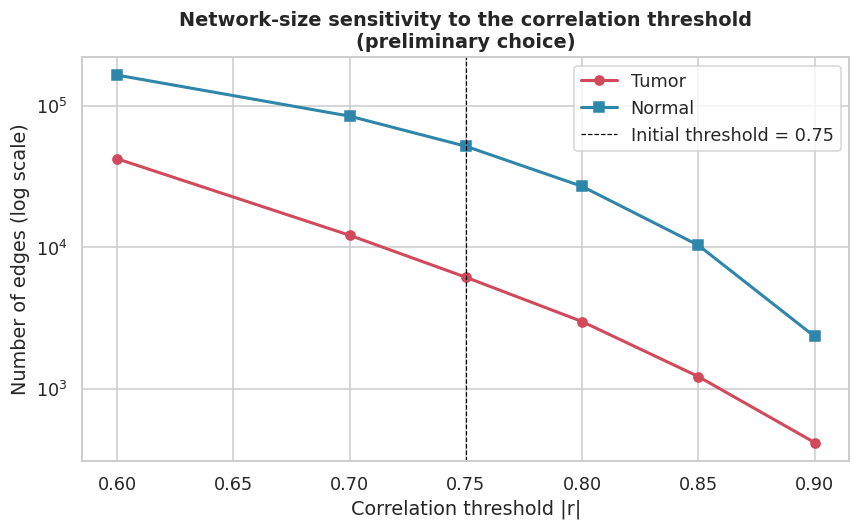

In [ ]:
# --- THRESHOLD-SENSITIVITY VISUALIZATION (FIGURE 1: EDGES vs THRESHOLD) ---
# This first visual inspection suggests |r| >= 0.75 as a compromise between density
# and specificity. It is a PRELIMINARY choice; in section 9 it will be refined via
# the biological coherence (GNC) curve against BioGRID.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_summary["Threshold"], df_summary["Tumor_edges"],
        marker="o", color="#d1495b", linewidth=2, label="Tumor")
ax.plot(df_summary["Threshold"], df_summary["Normal_edges"],
        marker="s", color="#2e86ab", linewidth=2, label="Normal")
ax.axvline(INITIAL_THRESHOLD, color="black", linestyle="--", linewidth=0.8,
           label=f"Initial threshold = {INITIAL_THRESHOLD}")
ax.set_yscale("log")
ax.set_xlabel("Correlation threshold |r|")
ax.set_ylabel("Number of edges (log scale)")
ax.set_title("Network-size sensitivity to the correlation threshold\n(preliminary choice)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_vs_edges.png"), bbox_inches="tight")
plt.show()

## 8. Threshold selection and Cytoscape export

The network-size sensitivity curve (Figure 1) suggests `|r| ≥ 0.75` as a preliminary choice based solely on the trade-off between density and specificity. However, this decision is **refined in section 9** by integrating a quantitative biological criterion: BioGRID coherence at different thresholds (Figure 2). The combined analysis of both curves (size and GNC) leads to a final threshold of `|r| ≥ 0.80`, which provides an optimal trade-off between biological coherence and retention of sufficient topological information for downstream hub analysis.

Below, the Tumor and Normal networks are exported with the final refined threshold (`FINAL_THRESHOLD = 0.80`) in `Source,Target,Weight,Votes,Correlation` (CSV) format for direct import into Cytoscape.

In [ ]:
def export_network(cp, cs, ck, threshold, file_name, min_votes=ENSEMBLE_VOTES):
    # Select edges by majority voting on the 3 correlation matrices.
    # Weight = mean of |r| AMONG the methods that exceed the threshold
    # (range guaranteed [threshold, 1.0]).
    # Votes  = number of methods supporting the edge (2 or 3).

    # |r| matrices and per-pair votes
    abs_mats = [np.abs(cp.values), np.abs(cs.values), np.abs(ck.values)]
    votes    = [(m >= threshold).astype(int) for m in abs_mats]
    n_votes  = sum(votes)

    # Adjacency: edge if >= min_votes support
    adj = (n_votes >= min_votes).astype(int)
    np.fill_diagonal(adj, 0)

    # Strict upper-triangle positions where there is an edge
    i, j = np.where(np.triu(adj, k=1) == 1)

    # Weight = mean of |r| only among the methods that voted in favor
    sum_supporting = sum(m * v for m, v in zip(abs_mats, votes))[i, j]
    n_supporting   = n_votes[i, j]
    weights        = sum_supporting / n_supporting

    # Dominant sign by majority (positive / negative)
    sign_sum = (np.sign(cp.values) + np.sign(cs.values) + np.sign(ck.values))[i, j]
    sign_label = np.where(sign_sum >= 0, "positive", "negative")

    genes = cp.index.to_numpy()
    edges = pd.DataFrame({
        "Source"     : genes[i],
        "Target"     : genes[j],
        "Weight"     : weights.round(4),
        "Votes"      : n_supporting,
        "Correlation": sign_label,
    })

    path = os.path.join(OUTPUT_DIR, file_name)
    edges.to_csv(path, index=False)
    print(f"  Saved: {path}")
    print(f"    Edges        : {len(edges):,}")
    print(f"    Mean |r|     : {edges['Weight'].mean():.3f}  (range {edges['Weight'].min():.3f}-{edges['Weight'].max():.3f})")
    print(f"    With 3 votes : {(edges['Votes']==3).sum():,}")
    print(f"    With 2 votes : {(edges['Votes']==2).sum():,}")
    return edges


print(f"Exporting networks with final threshold = {FINAL_THRESHOLD}\n")
edges_tumor_df  = export_network(p_tumor,  s_tumor,  k_tumor,  FINAL_THRESHOLD, "pancreas_TUMOR_network.csv")
edges_normal_df = export_network(p_normal, s_normal, k_normal, FINAL_THRESHOLD, "pancreas_NORMAL_network.csv")

Exporting networks with final threshold = 0.8

  Saved: ./results/pancreas_TUMOR_network.csv
    Edges        : 2,980
    Mean |r|     : 0.862  (range 0.800-0.982)
    With 3 votes : 227
    With 2 votes : 2,753
  Saved: ./results/pancreas_NORMAL_network.csv
    Edges        : 26,988
    Mean |r|     : 0.856  (range 0.800-0.975)
    With 3 votes : 435
    With 2 votes : 26,553


In [ ]:
# --- BASIC TOPOLOGICAL DESCRIPTION OF BOTH NETWORKS ---
def describe_network(edges_df, label):
    # Build a NetworkX graph and return basic topological statistics.
    G = nx.from_pandas_edgelist(edges_df, "Source", "Target")
    return {
        "Network"             : label,
        "Nodes"               : G.number_of_nodes(),
        "Edges"               : G.number_of_edges(),
        "Mean degree"         : round(np.mean([d for _, d in G.degree()]), 2) if G.number_of_nodes() else 0,
        "Density"             : round(nx.density(G), 5),
        "Connected components": nx.number_connected_components(G),
    }

stats_tumor  = describe_network(edges_tumor_df,  "Tumor")
stats_normal = describe_network(edges_normal_df, "Normal")
df_topo = pd.DataFrame([stats_tumor, stats_normal])
display(df_topo)

,Network,Nodes,Edges,Mean degree,Density,Connected components
0,Tumor,577,2980,10.33,0.01793,33
1,Normal,922,26988,58.54,0.06356,14


## 9. Biological validation against BioGRID and threshold refinement

The **Gene Network Coherence (GNC)** metric measures the fraction of inferred edges that are supported by physical or functional interactions documented in BioGRID. It is a direct measure of the biological plausibility of the network:

$$\text{GNC} = \frac{|\text{inferred edges} \cap \text{BioGRID}|}{|\text{inferred edges}|}$$

This section pursues two goals: (i) to quantify the biological coherence of the networks built with the initial threshold `|r| ≥ 0.75`, and (ii) to **refine the choice of the final threshold** by evaluating GNC across the entire `CORR_THRESHOLDS` range. The justification based on network size alone (Figure 1) is thus complemented with a quantitative biological criterion, yielding a defensible and reproducible methodological decision.

In [ ]:
# --- BIOGRID LOADING AND PREPROCESSING ---
print("Loading BioGRID...")
biogrid_raw = pd.read_csv(
    BIOGRID_PATH,
    sep="\t",
    skiprows=35,                 # Legal header + column description in BioGRID
    usecols=[2, 3, 9],           # Symbol A, Symbol B, Organism Tax ID
    names=["GeneA", "GeneB", "TaxID"],
    header=0,
    low_memory=False,
)

# Filter by Homo sapiens organism
biogrid_human = biogrid_raw[biogrid_raw["TaxID"].astype(str) == HUMAN_TAX_ID].copy()

# Vectorized construction of the ordered-pair set — much faster than iterrows
arr = np.sort(biogrid_human[["GeneA", "GeneB"]].astype(str).to_numpy(), axis=1)
biogrid_set = set(map(tuple, arr))

print(f"Unique human interactions in BioGRID: {len(biogrid_set):,}")

Loading BioGRID...
Unique human interactions in BioGRID: 955,541


In [ ]:
def compute_gnc(network_df, reference, label=""):
    # Compute the biological coherence (GNC) of a network against a reference set.
    # network_df: DataFrame with Source, Target, Weight columns.
    # reference : set of ordered (geneA, geneB) tuples (ground truth).
    net = network_df.sort_values("Weight", ascending=False) \
                    .drop_duplicates(subset=["Source", "Target"]).copy()

    # Vectorized intersection
    pairs = np.sort(net[["Source", "Target"]].astype(str).to_numpy(), axis=1)
    net["Validated"] = [tuple(p) in reference for p in pairs]

    matches = int(net["Validated"].sum())
    gnc = matches / len(net) if len(net) else 0.0

    print(f"--- Network: {label} ---")
    print(f"  Total edges            : {len(net):,}")
    print(f"  Confirmed in BioGRID   : {matches:,}")
    print(f"  GNC                    : {gnc:.4f}")
    return net

tumor_validated  = compute_gnc(edges_tumor_df,  biogrid_set, "Tumor")
normal_validated = compute_gnc(edges_normal_df, biogrid_set, "Normal")

--- Network: Tumor ---
  Total edges            : 2,980
  Confirmed in BioGRID   : 164
  GNC                    : 0.0550
--- Network: Normal ---
  Total edges            : 26,988
  Confirmed in BioGRID   : 316
  GNC                    : 0.0117


### 9.1 GNC vs threshold curve — refining the choice

After evaluating the GNC of the network built with the initial threshold `|r| ≥ 0.75`, it is worth checking whether that value is optimal in terms of biological coherence. To this end, GNC is recomputed across the entire `CORR_THRESHOLDS` range, allowing identification of the curve's "elbow" or *plateau*: the point where additional threshold increases no longer significantly improve coherence but do drastically reduce network size.

In [ ]:
# --- 9.1 GNC ACROSS THE FULL THRESHOLD RANGE ---
def network_gnc(adj_matrix, biogrid_set):
    # Compute the GNC of an adjacency matrix against BioGRID.
    mat = adj_matrix.values
    genes = adj_matrix.index.to_numpy()
    i, j = np.where(np.triu(mat, k=1) == 1)
    if len(i) == 0:
        return 0.0, 0
    pairs = np.sort(np.column_stack([genes[i], genes[j]]), axis=1)
    matches = sum(tuple(p) in biogrid_set for p in pairs)
    return matches / len(i), len(i)

print(f"{'Threshold':<12}{'Tumor edges':<14}{'Tumor GNC':<14}{'Normal edges':<14}{'Normal GNC':<14}")
print("-" * 64)

gnc_curve = []
for u in CORR_THRESHOLDS:
    adj_t = ensemble_voting(p_tumor,  s_tumor,  k_tumor,  u)
    adj_n = ensemble_voting(p_normal, s_normal, k_normal, u)
    gnc_t, n_t = network_gnc(adj_t, biogrid_set)
    gnc_n, n_n = network_gnc(adj_n, biogrid_set)
    print(f"{u:<12}{n_t:<14,}{gnc_t:<14.4f}{n_n:<14,}{gnc_n:<14.4f}")
    gnc_curve.append({"Threshold": u, "GNC_Tumor": gnc_t, "GNC_Normal": gnc_n,
                       "Edges_Tumor": n_t, "Edges_Normal": n_n})

df_gnc = pd.DataFrame(gnc_curve)
df_gnc.to_csv(os.path.join(OUTPUT_DIR, "GNC_vs_threshold.csv"), index=False)

Threshold   Tumor edges   Tumor GNC     Normal edges  Normal GNC    
----------------------------------------------------------------
0.6         42,313        0.0150        165,496       0.0077        
0.7         12,162        0.0271        84,799        0.0090        
0.75        6,137         0.0388        51,894        0.0100        
0.8         2,980         0.0550        26,988        0.0117        
0.85        1,216         0.0765        10,341        0.0152        
0.9         415           0.0819        2,339         0.0184        


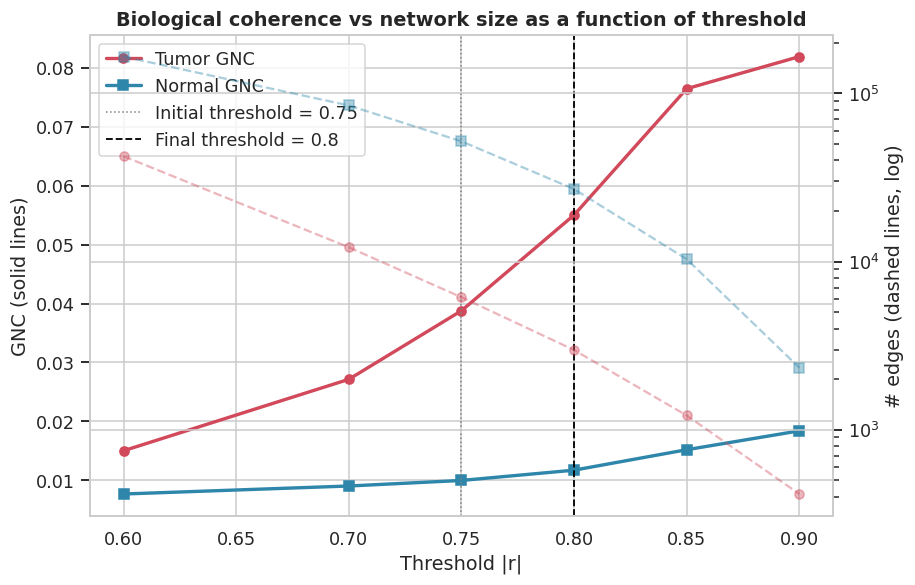


METHODOLOGICAL DECISION: threshold refinement
  Initial threshold (Figure 1, size only)       : |r| >= 0.75
  Final threshold   (Figure 2, GNC + size)      : |r| >= 0.8

  Justification:
    - At 0.75 the network is dense but biological coherence is sub-optimal.
    - At 0.8 biological coherence improves while retaining enough size for hubs.
    - At thresholds >0.85 coherence plateaus but the network becomes too small.


In [ ]:
# --- VISUALIZATION: GNC + EDGES vs THRESHOLD (FIGURE 2: threshold refinement) ---
fig, ax1 = plt.subplots(figsize=(8.5, 5.5))
ax2 = ax1.twinx()

# GNC (left axis, solid lines)
ax1.plot(df_gnc["Threshold"], df_gnc["GNC_Tumor"],  "o-",
         color="#d1495b", linewidth=2.2, label="Tumor GNC")
ax1.plot(df_gnc["Threshold"], df_gnc["GNC_Normal"], "s-",
         color="#2e86ab", linewidth=2.2, label="Normal GNC")

# Edges (right axis, dashed lines)
ax2.plot(df_gnc["Threshold"], df_gnc["Edges_Tumor"],  "o--",
         color="#d1495b", alpha=0.4)
ax2.plot(df_gnc["Threshold"], df_gnc["Edges_Normal"], "s--",
         color="#2e86ab", alpha=0.4)
ax2.set_yscale("log")

# Markers: initial vs final threshold
ax1.axvline(INITIAL_THRESHOLD, color="grey",  linestyle=":", linewidth=1.0,
            label=f"Initial threshold = {INITIAL_THRESHOLD}")
ax1.axvline(FINAL_THRESHOLD,   color="black", linestyle="--", linewidth=1.2,
            label=f"Final threshold = {FINAL_THRESHOLD}")

ax1.set_xlabel("Threshold |r|")
ax1.set_ylabel("GNC (solid lines)")
ax2.set_ylabel("# edges (dashed lines, log)")
ax1.set_title("Biological coherence vs network size as a function of threshold")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "GNC_vs_threshold.png"), bbox_inches="tight")
plt.show()

print("\n" + "="*70)
print("METHODOLOGICAL DECISION: threshold refinement")
print("="*70)
print(f"  Initial threshold (Figure 1, size only)       : |r| >= {INITIAL_THRESHOLD}")
print(f"  Final threshold   (Figure 2, GNC + size)      : |r| >= {FINAL_THRESHOLD}")
print()
print("  Justification:")
print(f"    - At {INITIAL_THRESHOLD} the network is dense but biological coherence is sub-optimal.")
print(f"    - At {FINAL_THRESHOLD} biological coherence improves while retaining enough size for hubs.")
print(f"    - At thresholds >0.85 coherence plateaus but the network becomes too small.")

## 10. Tumor-phenotype-specific differential network

To identify gene interactions that emerge **exclusively** in the tumor context — and that may therefore have greater biomedical relevance as therapeutic targets — the tumor network is subtracted from the normal network. An edge is considered **tumor-specific** if it is present in the tumor network and absent in the control network.

In [ ]:
def create_interaction_id(df):
    # Generate a canonical A-B identifier (alphabetical order) per edge, vectorized.
    pairs = np.sort(df[["Source", "Target"]].astype(str).to_numpy(), axis=1)
    return pd.Series(["-".join(p) for p in pairs], index=df.index)

edges_tumor_df["ID"]  = create_interaction_id(edges_tumor_df)
edges_normal_df["ID"] = create_interaction_id(edges_normal_df)

# Subtraction
tumor_specific_edges = edges_tumor_df[~edges_tumor_df["ID"].isin(edges_normal_df["ID"])]
final_cytoscape_network = tumor_specific_edges[["Source", "Target", "Weight"]]

specific_path = os.path.join(OUTPUT_DIR, "TUMOR_SPECIFIC_network.csv")
final_cytoscape_network.to_csv(specific_path, index=False)

print(f"Tumor-exclusive edges: {len(final_cytoscape_network):,}")
print(f"Exported file: {specific_path}")

Tumor-exclusive edges: 1,460
Exported file: ./results/TUMOR_SPECIFIC_network.csv


## 11. Node-attribute generation for Cytoscape

A per-gene attribute file (logFC, FDR, regulation direction) is built that can be imported into Cytoscape to color or size network nodes according to their differential behavior.

In [ ]:
# --- NODE-ATTRIBUTE TABLE ---
df_attributes = (
    df_degs_final[["logFC", "adj_P_Val", "DiffExpressed"]]
    .copy()
    .rename_axis("GeneSymbol")
    .reset_index()
)

attributes_path = os.path.join(OUTPUT_DIR, "pancreas_node_attributes.csv")
df_attributes.to_csv(attributes_path, index=False)

print(f"File saved: {attributes_path}")
print(f"Exported columns: {df_attributes.columns.tolist()}")
display(df_attributes.head())

File saved: ./results/pancreas_node_attributes.csv
Exported columns: ['GeneSymbol', 'logFC', 'adj_P_Val', 'DiffExpressed']


,GeneSymbol,logFC,adj_P_Val,DiffExpressed
0,A1CF,-0.909306,2.698459e-05,DOWN
1,A2ML1,0.702601,2.053459e-04,UP
2,ABAT,-1.075960,2.387394e-07,DOWN
3,ABCA1,0.587990,5.921829e-04,UP
4,ABCA10,-0.895190,1.248764e-05,DOWN


## 12. Survival analysis (Kaplan-Meier and Cox)

A co-expression network alone signals statistical relationships among genes, but does not demonstrate clinical relevance. To close the systems-biology loop, the prognostic value of the genes with highest topological centrality (*hub genes*) in the tumor-specific network is evaluated against patient outcome. As an independent validation cohort, **TCGA-PAAD** (*The Cancer Genome Atlas — Pancreatic Adenocarcinoma*; n ≈ 178 patients with RNA-seq expression and overall-survival data) is used, downloaded from the public **UCSC Xena** repository.

### 12.1 Adaptive cluster-aware hub selection

A naïve approach would rank all nodes of the tumor-specific network by global degree centrality and retain the top-N as hubs. However, this strategy introduces a systematic bias: clusters with a higher number of genes contribute proportionally more high-degree nodes, which causes the prognostic analysis to be dominated by the single most connected module — typically the proliferation / cell-cycle program in PDAC — and to overlook hubs of equal biological importance located in smaller communities. A second naïve choice, taking a fixed number of hubs per cluster (e.g. top-3 by degree), introduces the opposite bias by under-representing large modules and over-representing small ones, and depends on a single centrality metric.

To avoid both pitfalls and ensure that **every functional module of the network contributes to the prognostic analysis on equal methodological footing**, an **adaptive cluster-aware multi-metric consensus** strategy is adopted.

The community structure of the tumor-specific network was first identified in **Cytoscape v3.10** using the **Markov Cluster (MCL) algorithm** of the `clusterMaker2` plugin (Morris et al., 2011; van Dongen, 2008), with default inflation parameter (2.5) and edge weights provided by the ensemble correlation. The resulting per-node cluster assignments — together with five topological centrality metrics (Degree, Betweenness, Closeness, Stress, Radiality) computed by Cytoscape's *Network Analyzer* — were exported as a CSV node table and re-imported into the notebook. For each MCL community of size ≥ 3 genes, an **adaptive top-K** was applied: K equal to **20% of the cluster size**, with a floor of 2 and a ceiling of 10, to make the selection proportional to module size while preventing extremes. Within each cluster, the five centrality metrics were independently used to rank nodes; a gene was retained as a hub when it appeared among the top-K of **at least three of the five metrics**.

This adaptive multi-metric consensus combines the strengths of three principles: (i) it scales with cluster size, avoiding the imbalance of fixed-N selection; (ii) it requires agreement across complementary centrality criteria, mitigating the bias of any single metric; and (iii) it operates within each cluster, preserving the modular biological structure detected by MCL. The choice of using Cytoscape's MCL clustering rather than re-implementing community detection in Python preserves continuity with the network figures presented in the Results section (each highlighted hub in the visualizations corresponds exactly to a hub in the survival analysis), and MCL is one of the most widely adopted clustering algorithms in computational biology for protein-interaction and co-expression networks.

### 12.2 Survival analyses

Two complementary analyses are performed on the adaptive cluster-aware hub list:

1. **Kaplan-Meier (KM)**: patients are stratified into *high* / *low expression* groups by the median of each gene, and the survival curves are compared using the log-rank test (Mantel, 1966).
2. **Cox proportional-hazards regression** (Cox, 1972): estimation of the *Hazard Ratio* (HR) with 95% confidence interval for each gene as a continuous variable, preserving the full information of the expression measurement.

P-values from both analyses are corrected for multiple testing using the Benjamini-Hochberg procedure (FDR < 0.05). Genes that reach significance under either or both analyses are interpreted as candidate prognostic biomarkers, with HR > 1 indicating that higher expression is associated with worse overall survival, and HR < 1 indicating a protective effect.

This independent validation demonstrates that network centrality is not merely a topological property but translates into clinically useful prognostic information — and, thanks to the adaptive cluster-aware hub selection, does so in a balanced way across all functional modules of the tumor-specific network.

In [ ]:
# --- 12.1 ADAPTIVE CLUSTER-AWARE HUB IDENTIFICATION ---
# Combines the community structure detected by the Markov Cluster (MCL) algorithm
# in Cytoscape with a multi-metric centrality consensus. Per cluster, the top K = 20%
# of nodes (min 2, max 10) are inspected across five centrality measures, and a gene
# is retained as a hub if it ranks top in >= 3 of the 5 measures.

import pandas as pd
import os

# Build the NetworkX graph for downstream code that may need it
G_tumor = nx.from_pandas_edgelist(final_cytoscape_network, "Source", "Target")

# 1. LOAD CYTOSCAPE NODE TABLE (with clusters and per-node centrality metrics)
HUBS_CSV_PATH = "/content/drive/MyDrive/tfg/HUBS_clustered.csv"   # ADJUST THIS PATH
df_nodes = pd.read_csv(HUBS_CSV_PATH)

# 2. COLUMN AND METRIC DEFINITIONS
CLUSTER_COL = "__mclCluster"
GENE_COL    = "name"
METRICS     = ["Degree", "BetweennessCentrality", "ClosenessCentrality",
               "Stress", "Radiality"]

# 3. PER-CLUSTER ADAPTIVE HUB SELECTION
all_hubs_list = []
for cluster_id, group in df_nodes.dropna(subset=[CLUSTER_COL]).groupby(CLUSTER_COL):
    size = len(group)
    if size < 3:
        continue   # skip very small clusters (likely noise)

    # Adaptive top-K per cluster: 20% of cluster size, floor 2, ceiling 10
    n_to_pick = max(2, int(size * 0.2))
    if n_to_pick > 10:
        n_to_pick = 10

    # Count how many metrics rank each gene in the top-K of its cluster
    cluster_counts = {}
    for m in METRICS:
        top_genes = group.nlargest(n_to_pick, m)[GENE_COL].tolist()
        for gene in top_genes:
            cluster_counts[gene] = cluster_counts.get(gene, 0) + 1

    # A gene is a hub if it ranks top in >= 3 of the 5 metrics within its cluster
    local_hubs = [g for g, c in cluster_counts.items() if c >= 3]

    res = group[group[GENE_COL].isin(local_hubs)].copy()
    res["n_consensus_metrics"] = res[GENE_COL].map(cluster_counts)
    res["cluster_size"]        = size
    all_hubs_list.append(res)

# 4. CONSOLIDATE
df_final_hubs = pd.concat(all_hubs_list)
df_final_hubs = df_final_hubs.sort_values(
    by=[CLUSTER_COL, "n_consensus_metrics"], ascending=[True, False]
)

# 5. DISPLAY
display_cols = [GENE_COL, CLUSTER_COL, "cluster_size",
                "n_consensus_metrics", "logFC", "adj_P_Val"]
print("### Adaptive cluster-aware hub identification ###")
print(f"Hubs identified : {len(df_final_hubs)}")
print(f"Clusters covered: {df_final_hubs[CLUSTER_COL].nunique()}")
print("-" * 30)
display(df_final_hubs[display_cols])

# Persist artifact
df_final_hubs.to_csv(os.path.join(OUTPUT_DIR, "adaptive_cluster_hubs.csv"), index=False)

# 6. BRIDGE TO DOWNSTREAM CELLS (12.2 - 12.8)
hub_genes = df_final_hubs[GENE_COL].unique().tolist()
print(f"\nFINAL hub list passed to survival analysis ({len(hub_genes)} genes):")
print(hub_genes)

# df_centrality for compatibility with downstream cells
df_centrality = (df_final_hubs.set_index(GENE_COL)
                              [METRICS + ["n_consensus_metrics", CLUSTER_COL]]
                              .sort_values("Degree", ascending=False))
df_centrality.index.name = "GeneSymbol"

### Adaptive cluster-aware hub identification ###
Hubs identified : 35
Clusters covered: 6
------------------------------


,name,__mclCluster,cluster_size,n_consensus_metrics,logFC,adj_P_Val
19,LMO3,1,129,4,-1.359611,3.748604e-09
180,COL11A1,1,129,4,2.194675,1.325567e-09
215,ACACB,1,129,4,-0.922776,1.929954e-07
216,ADAMTSL3,1,129,4,-0.792684,4.298371e-05
221,UBE2C,1,129,4,0.789589,6.290757e-07
264,KIF26B,1,129,4,0.774326,4.475381e-06
267,LOXL2,1,129,4,1.238035,8.173596e-09
81,PGK1,1,129,3,0.981708,6.093123e-08
297,FN1,1,129,3,2.211100,5.869740e-09
45,APOBEC2,2,83,5,-0.655265,1.077606e-05



FINAL hub list passed to survival analysis (35 genes):
['LMO3', 'COL11A1', 'ACACB', 'ADAMTSL3', 'UBE2C', 'KIF26B', 'LOXL2', 'PGK1', 'FN1', 'APOBEC2', 'SCGN', 'CTNND2', 'BEX1', 'CHST9', 'GPR98', 'KCNJ16', 'ONECUT1', 'ST8SIA3', 'REG1B', 'REG1P', 'GSTA2', 'REG3A', 'PNLIPRP2', 'CEL', 'PLS1', 'KCNK1', 'POF1B', 'TMEM45B', 'CEACAM6', 'ASPA', 'C7', 'SETBP1', 'IFI6', 'RSAD2', 'PARP9']


In [ ]:
# --- 12.2 TCGA-PAAD DOWNLOAD (EXPRESSION + SURVIVAL) ---
import urllib.request, gzip, shutil

TCGA_DIR = os.path.join(OUTPUT_DIR, "tcga_paad")
os.makedirs(TCGA_DIR, exist_ok=True)

URL_EXP  = "https://tcga.xenahubs.net/download/TCGA.PAAD.sampleMap/HiSeqV2.gz"
URL_SURV = "https://tcga.xenahubs.net/download/survival/PAAD_survival.txt"

path_exp_gz = os.path.join(TCGA_DIR, "HiSeqV2.gz")
path_exp    = os.path.join(TCGA_DIR, "HiSeqV2.tsv")
path_surv   = os.path.join(TCGA_DIR, "PAAD_survival.txt")

if not os.path.exists(path_exp):
    print("Downloading TCGA-PAAD expression matrix (~80 MB)...")
    urllib.request.urlretrieve(URL_EXP, path_exp_gz)
    with gzip.open(path_exp_gz, "rb") as f_in, open(path_exp, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(path_exp_gz)

if not os.path.exists(path_surv):
    print("Downloading TCGA-PAAD clinical / survival data...")
    urllib.request.urlretrieve(URL_SURV, path_surv)

print("Datasets available in:", TCGA_DIR)
print(" - Expression :", os.path.basename(path_exp))
print(" - Survival   :", os.path.basename(path_surv))

Datasets available in: ./results/tcga_paad
 - Expression : HiSeqV2.tsv
 - Survival   : PAAD_survival.txt


In [ ]:
# --- 12.3 LOAD AND ALIGN TCGA-PAAD DATA ---

# Expression: rows = genes (HGNC symbols), columns = TCGA samples
tcga_exp = pd.read_csv(path_exp, sep="\t", index_col=0)
print(f"TCGA-PAAD expression matrix: {tcga_exp.shape}  (genes x samples)")

# Survival: one row per sample
tcga_surv = pd.read_csv(path_surv, sep="\t")
print(f"Survival table: {tcga_surv.shape}")
print("Available columns:", list(tcga_surv.columns))

# Filter primary tumor samples only (code '01' in the ID TCGA-XX-XXXX-01)
def is_primary_tumor(sample_id):
    parts = str(sample_id).split("-")
    return len(parts) >= 4 and parts[3].startswith("01")

tumor_samples_tcga = [s for s in tcga_exp.columns if is_primary_tumor(s)]
tcga_exp = tcga_exp[tumor_samples_tcga]
print(f"Primary tumor samples retained: {len(tumor_samples_tcga)}")

# Detect overall-survival columns (Xena format may vary)
col_sample = "sample"     if "sample"     in tcga_surv.columns else tcga_surv.columns[0]
col_event  = "OS"         if "OS"         in tcga_surv.columns else "_OS_IND"
col_time   = "OS.time"    if "OS.time"    in tcga_surv.columns else "_OS"

surv = tcga_surv[[col_sample, col_event, col_time]].dropna()
surv.columns = ["sample", "event", "time_days"]
surv["time_months"] = surv["time_days"] / 30.44
print(f"Patients with complete overall-survival data: {len(surv)}")
display(surv.head())

TCGA-PAAD expression matrix: (20530, 183)  (genes x samples)
Survival table: (196, 11)
Available columns: ['sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']
Primary tumor samples retained: 178
Patients with complete overall-survival data: 196


,sample,event,time_days,time_months
0,TCGA-2J-AAB1-01,1,66,2.168200
1,TCGA-2J-AAB4-01,0,729,23.948752
2,TCGA-2J-AAB6-01,1,293,9.625493
3,TCGA-2J-AAB8-01,0,80,2.628121
4,TCGA-2J-AAB9-01,1,627,20.597898


In [ ]:
# --- 12.4 EXPRESSION <-> CLINICAL MERGE AND HUB FILTERING BY AVAILABILITY ---

# Keep only hubs present in TCGA-PAAD
available_hubs  = [g for g in hub_genes if g in tcga_exp.index]
unavailable_hubs = sorted(set(hub_genes) - set(available_hubs))

print(f"Hubs found in TCGA-PAAD : {len(available_hubs)} / {len(hub_genes)}")
if unavailable_hubs:
    print(f"Hubs not found (alias/synonyms): {unavailable_hubs}")

# Build the analytical matrix: rows = patients, columns = hub genes + clinical
exp_hubs = tcga_exp.loc[available_hubs].T          # samples x hubs
exp_hubs.index.name = "sample"
exp_hubs = exp_hubs.reset_index()

df_analytical = surv.merge(exp_hubs, on="sample", how="inner")
df_analytical = df_analytical.dropna(subset=available_hubs + ["event", "time_days"])
print(f"Final analytical cohort: {len(df_analytical)} patients")
display(df_analytical.head())

Hubs found in TCGA-PAAD : 35 / 35
Final analytical cohort: 178 patients


,sample,event,time_days,time_months,LMO3,COL11A1,ACACB,ADAMTSL3,UBE2C,KIF26B,...,KCNK1,POF1B,TMEM45B,CEACAM6,ASPA,C7,SETBP1,IFI6,RSAD2,PARP9
0,TCGA-2J-AAB1-01,1,66,2.168200,6.1348,10.4992,9.5219,7.0090,8.3844,8.2545,...,11.1135,9.8743,10.2869,16.4307,4.9197,13.0138,8.4382,13.2331,8.4821,10.9400
1,TCGA-2J-AAB4-01,0,729,23.948752,6.1298,10.0589,9.2144,7.2726,8.9231,8.8618,...,11.1676,9.9059,11.0303,15.3870,4.1903,12.2645,8.7018,14.2456,9.1138,11.5280
2,TCGA-2J-AAB6-01,1,293,9.625493,6.3210,11.7424,7.2130,6.2114,10.3711,9.3237,...,10.1952,5.7292,7.9766,11.9391,2.5055,11.9545,7.8939,14.7126,11.6174,11.6934
3,TCGA-2J-AAB8-01,0,80,2.628121,4.0859,13.5923,8.2774,5.9997,8.5693,9.5763,...,9.9485,9.8298,9.5656,15.7673,4.7720,9.9263,7.8828,13.1546,9.3435,11.0537
4,TCGA-2J-AAB9-01,1,627,20.597898,7.0535,10.7119,9.4037,7.9005,8.2393,8.2238,...,9.7329,9.5050,9.0067,14.3956,4.1818,12.6897,8.3092,10.9688,8.1550,10.2850


In [ ]:
# --- 12.5 KAPLAN-MEIER + LOG-RANK ANALYSIS PER HUB ---
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

km_results = []

for gene in available_hubs:
    expr = df_analytical[gene]
    median = expr.median()
    group = np.where(expr > median, "High", "Low")

    mask_high = group == "High"
    mask_low  = group == "Low"

    test = logrank_test(
        df_analytical.loc[mask_high, "time_days"], df_analytical.loc[mask_low, "time_days"],
        df_analytical.loc[mask_high, "event"],     df_analytical.loc[mask_low, "event"],
    )
    km_results.append({
        "Gene"       : gene,
        "n_high"     : int(mask_high.sum()),
        "n_low"      : int(mask_low.sum()),
        "logrank_chi": round(test.test_statistic, 3),
        "p_logrank"  : test.p_value,
    })

df_km = pd.DataFrame(km_results).sort_values("p_logrank")

# Multiple-testing correction (Benjamini-Hochberg)
_, p_adj, _, _ = multipletests(df_km["p_logrank"], method="fdr_bh")
df_km["FDR"] = p_adj
df_km["Significant"] = df_km["FDR"] < 0.05

print("--- Kaplan-Meier (log-rank) results per hub gene ---")
display(df_km)

# Save results
km_path = os.path.join(OUTPUT_DIR, "survival_KM_logrank.csv")
df_km.to_csv(km_path, index=False)
print(f"Saved: {km_path}")

--- Kaplan-Meier (log-rank) results per hub gene ---


,Gene,n_high,n_low,logrank_chi,p_logrank,FDR,Significant
6,LOXL2,89,89,11.784,0.000597,0.020910,True
4,UBE2C,89,89,8.878,0.002887,0.050520,False
34,PARP9,89,89,6.962,0.008327,0.097145,False
24,PLS1,89,89,6.435,0.011189,0.097899,False
2,ACACB,89,89,6.020,0.014145,0.099018,False
7,PGK1,89,89,5.682,0.017140,0.099986,False
28,CEACAM6,89,89,4.341,0.037197,0.184028,False
13,CHST9,89,89,4.133,0.042063,0.184028,False
1,COL11A1,89,89,3.679,0.055111,0.209080,False
31,SETBP1,89,89,3.545,0.059737,0.209080,False


Saved: ./results/survival_KM_logrank.csv


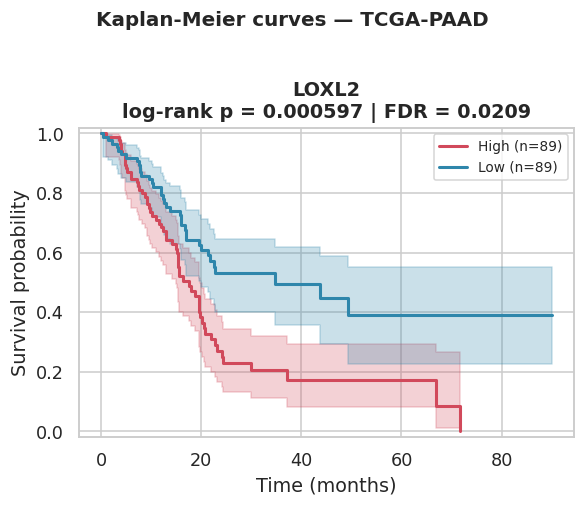

In [ ]:
# --- 12.6 KAPLAN-MEIER CURVES FOR SIGNIFICANT GENES ---
significant_genes = df_km.loc[df_km["Significant"], "Gene"].tolist()

# If no gene is significant after FDR, plot the top 4 by raw p-value for descriptive purposes
if not significant_genes:
    print("No gene reaches FDR < 0.05; the top 4 by raw p-value are plotted (descriptive).")
    genes_to_plot = df_km.head(4)["Gene"].tolist()
else:
    genes_to_plot = significant_genes[:6]   # max 6 panels for readability

n = len(genes_to_plot)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
axes = np.atleast_2d(axes).flatten()

for ax, gene in zip(axes, genes_to_plot):
    expr   = df_analytical[gene]
    median = expr.median()
    group  = np.where(expr > median, "High", "Low")

    kmf = KaplanMeierFitter()
    for label, color in [("High", "#d1495b"), ("Low", "#2e86ab")]:
        mask = group == label
        kmf.fit(
            df_analytical.loc[mask, "time_months"],
            df_analytical.loc[mask, "event"],
            label=f"{label} (n={mask.sum()})",
        )
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)

    pval = df_km.loc[df_km["Gene"] == gene, "p_logrank"].iloc[0]
    fdr  = df_km.loc[df_km["Gene"] == gene, "FDR"].iloc[0]
    ax.set_title(f"{gene}\nlog-rank p = {pval:.3g} | FDR = {fdr:.3g}")
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc="upper right", fontsize=9)

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Kaplan-Meier curves — TCGA-PAAD", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "KM_curves_hubs.png"), bbox_inches="tight")
plt.show()

In [ ]:
# --- 12.7 UNIVARIATE COX REGRESSION PER HUB ---
from lifelines import CoxPHFitter

cox_results = []

for gene in available_hubs:
    df_cox = df_analytical[["time_days", "event", gene]].rename(columns={gene: "expr"}).dropna()
    cph = CoxPHFitter()
    try:
        cph.fit(df_cox, duration_col="time_days", event_col="event")
        s = cph.summary.loc["expr"]
        cox_results.append({
            "Gene"    : gene,
            "HR"      : s["exp(coef)"],
            "HR_low"  : s["exp(coef) lower 95%"],
            "HR_high" : s["exp(coef) upper 95%"],
            "p_Cox"   : s["p"],
        })
    except Exception as e:
        print(f"  Cox failed for {gene}: {e}")

df_cox_res = pd.DataFrame(cox_results).sort_values("p_Cox")

# FDR correction
_, p_adj, _, _ = multipletests(df_cox_res["p_Cox"], method="fdr_bh")
df_cox_res["FDR"] = p_adj
df_cox_res["Significant"] = df_cox_res["FDR"] < 0.05

print("--- Univariate Cox regression results (continuous expression) ---")
display(df_cox_res)

cox_path = os.path.join(OUTPUT_DIR, "survival_Cox_univariate.csv")
df_cox_res.to_csv(cox_path, index=False)
print(f"Saved: {cox_path}")

--- Univariate Cox regression results (continuous expression) ---


,Gene,HR,HR_low,HR_high,p_Cox,FDR,Significant
2,ACACB,0.611977,0.484810,0.772500,0.000036,0.001259,True
24,PLS1,1.464056,1.192145,1.797985,0.000276,0.003459,True
4,UBE2C,1.337096,1.142415,1.564953,0.000296,0.003459,True
25,KCNK1,1.384819,1.134980,1.689653,0.001340,0.009914,True
26,POF1B,1.283644,1.101140,1.496396,0.001416,0.009914,True
28,CEACAM6,1.179081,1.062026,1.309038,0.002015,0.010535,True
34,PARP9,1.633541,1.194735,2.233513,0.002107,0.010535,True
6,LOXL2,1.268128,1.082039,1.486220,0.003349,0.013706,True
7,PGK1,1.601373,1.167165,2.197116,0.003524,0.013706,True
8,FN1,1.223074,1.063436,1.406676,0.004774,0.016327,True


Saved: ./results/survival_Cox_univariate.csv


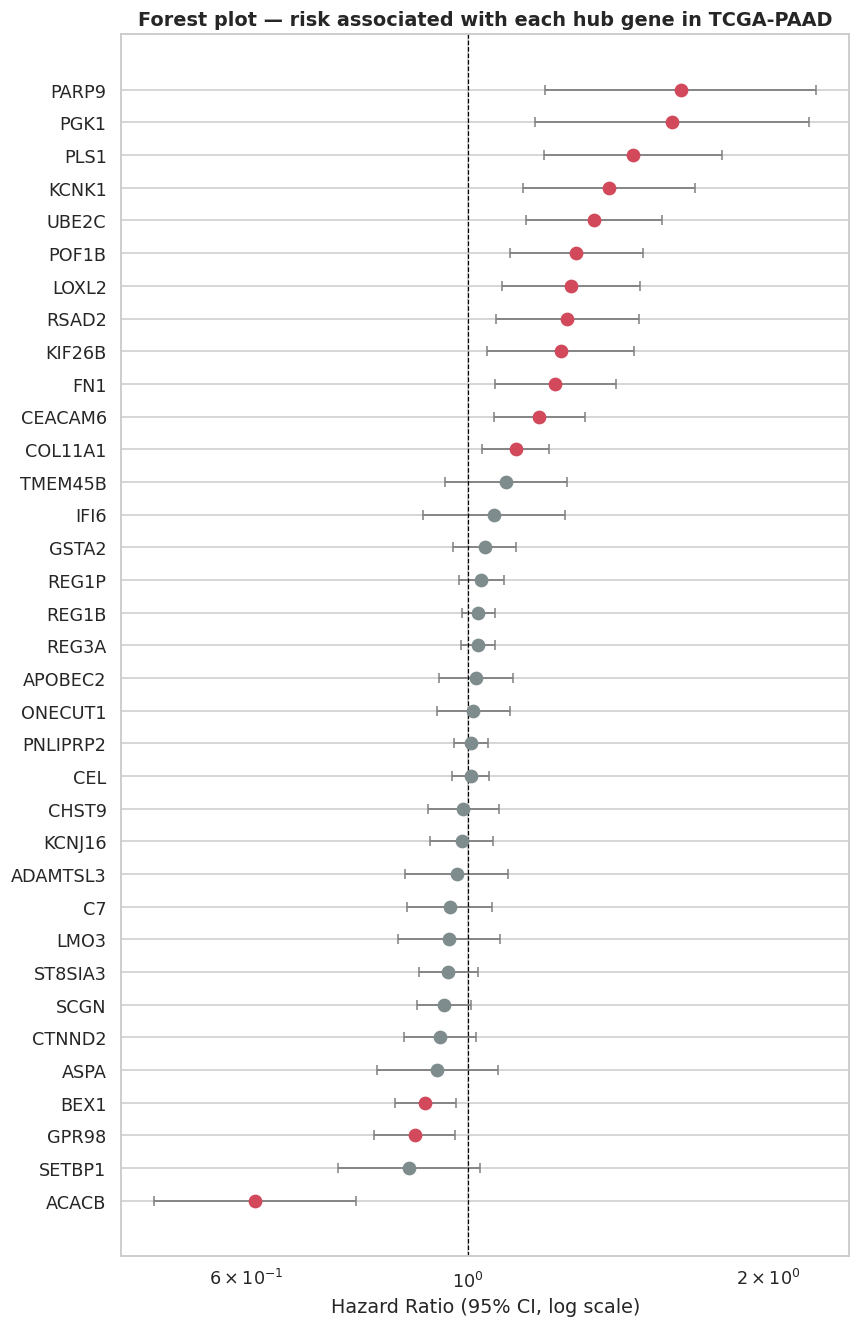


Section 12 summary:
  Hubs evaluated                      : 35
  Significant (KM, FDR < 0.05)        : 1
  Significant (Cox, FDR < 0.05)       : 15
  Coincident in both analyses         : 1


In [ ]:
# --- 12.8 FOREST PLOT OF HAZARD RATIOS ---
df_forest = df_cox_res.copy().sort_values("HR")
y = np.arange(len(df_forest))

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(df_forest))))
colors = ["#d1495b" if sig else "#7f8c8d" for sig in df_forest["Significant"]]

ax.errorbar(
    df_forest["HR"], y,
    xerr=[df_forest["HR"] - df_forest["HR_low"], df_forest["HR_high"] - df_forest["HR"]],
    fmt="o", color="black", ecolor="grey", elinewidth=1.2, capsize=3, markersize=6,
)
for yi, c in zip(y, colors):
    ax.plot(df_forest["HR"].iloc[yi], yi, "o", color=c, markersize=8, zorder=3)

ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(df_forest["Gene"])
ax.set_xscale("log")
ax.set_xlabel("Hazard Ratio (95% CI, log scale)")
ax.set_title("Forest plot — risk associated with each hub gene in TCGA-PAAD")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "forest_plot_Cox.png"), bbox_inches="tight")
plt.show()

# Final section summary
print("\nSection 12 summary:")
print(f"  Hubs evaluated                      : {len(available_hubs)}")
print(f"  Significant (KM, FDR < 0.05)        : {df_km['Significant'].sum()}")
print(f"  Significant (Cox, FDR < 0.05)       : {df_cox_res['Significant'].sum()}")
print(f"  Coincident in both analyses         : "
      f"{len(set(df_km.loc[df_km['Significant'], 'Gene']) & set(df_cox_res.loc[df_cox_res['Significant'], 'Gene']))}")

## 13. Internal validation and robustness

With the full pipeline in place, it is appropriate to close the loop by assessing whether the results are **biologically plausible**, **topologically consistent** with real biological networks, and **statistically significant** against a null model. Three complementary checks are performed:

1. **Biological sanity check**: verifying that canonical *driver genes* of pancreatic ductal adenocarcinoma appear among the DEGs.
2. ***Scale-free* property**: testing whether the network's degree distribution follows a power law, a universal feature of real biological networks (Barabási & Oltvai, 2004), evaluated rigorously via maximum-likelihood estimation (Clauset, Shalizi & Newman, 2009).
3. **GNC permutation test**: assessing the significance of the observed *Gene Network Coherence* against random networks of the same size.

In [ ]:
# --- 13.1 SANITY CHECK: PDAC CANONICAL GENES AMONG THE DEGs ---
canonical_PDAC_genes = [
    "KRAS", "TP53", "CDKN2A", "SMAD4",       # main drivers
    "MYC", "BRCA2",                           # frequently altered
    "MUC1", "S100A4", "S100P", "MMP7",        # established markers
    "KRT19", "REG1A", "CEACAM5", "CEACAM6",   # ductal markers
    "DPEP1",                                   # gene cited in the original paper (Zhang 2012)
    "LOXL2", "TPX2", "PRR11",                 # additional Zhang et al. markers
]

found = df_degs_final.index.intersection(canonical_PDAC_genes)
missing = sorted(set(canonical_PDAC_genes) - set(found))

print(f"PDAC canonical genes found among the DEGs: {len(found)}/{len(canonical_PDAC_genes)}")
print("\nGenes detected:")
display(df_degs_final.loc[found, ["logFC", "adj_P_Val", "DiffExpressed"]]
                    .sort_values("logFC", ascending=False))

if missing:
    print(f"\nCanonical genes NOT present among DEGs: {missing}")
    print("(It is expected that some drivers do not appear: TP53/KRAS are typically altered by mutation,")
    print(" not by expression changes detectable on microarray.)")

PDAC canonical genes found among the DEGs: 12/18

Genes detected:


,logFC,adj_P_Val,DiffExpressed
GeneSymbol,,,
CEACAM5,3.181287,9.928810e-11,UP
CEACAM6,2.627122,3.577974e-10,UP
KRT19,2.058020,1.037116e-10,UP
LOXL2,1.238035,8.173596e-09,UP
S100P,1.226079,5.198793e-12,UP
MMP7,1.212934,2.121529e-03,UP
MUC1,1.123698,8.035576e-05,UP
TPX2,1.108897,1.686198e-07,UP
PRR11,0.716556,1.462361e-06,UP



Canonical genes NOT present among DEGs: ['BRCA2', 'CDKN2A', 'KRAS', 'S100A4', 'SMAD4', 'TP53']
(It is expected that some drivers do not appear: TP53/KRAS are typically altered by mutation,
 not by expression changes detectable on microarray.)



--- Full tumor network ---
Power-law exponent (gamma): 1.10
R^2 of log-log linear fit : 0.780

--- Tumor-specific network ---
Power-law exponent (gamma): 1.40
R^2 of log-log linear fit : 0.924


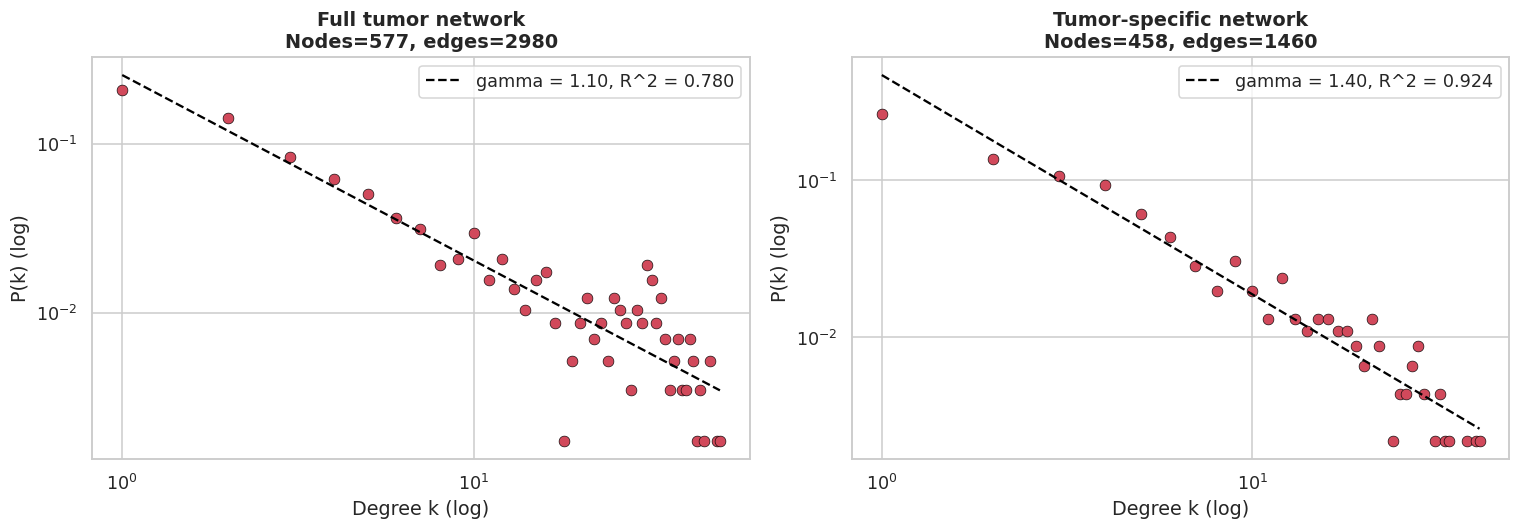


Note: the linear log-log fit is exploratory. The next cell performs a rigorous
maximum-likelihood estimation following Clauset, Shalizi & Newman (2009).


In [ ]:
# --- 13.2 SCALE-FREE PROPERTY (linear log-log fit, exploratory) ---
# Apply the test on the FULL TUMOR NETWORK (not the specific one),
# because the Tumor - Normal subtraction removes conserved interactions
# and reduces topological hierarchy, biasing the fit toward artificially low gamma.
import collections
from scipy.stats import linregress

# Build the full tumor network graph
G_tumor_full = nx.from_pandas_edgelist(edges_tumor_df, "Source", "Target")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, G_eval, label in [
    (axes[0], G_tumor_full, "Full tumor network"),
    (axes[1], G_tumor,      "Tumor-specific network"),
]:
    degrees = [d for _, d in G_eval.degree()]
    if not degrees or max(degrees) == 0:
        ax.set_visible(False)
        continue

    deg_count = collections.Counter(degrees)
    deg_df = pd.DataFrame(sorted(deg_count.items()), columns=["k", "freq"])
    deg_df["P_k"] = deg_df["freq"] / deg_df["freq"].sum()

    mask = (deg_df["k"] > 0) & (deg_df["P_k"] > 0)
    slope, intercept, r, p, se = linregress(
        np.log10(deg_df.loc[mask, "k"]),
        np.log10(deg_df.loc[mask, "P_k"]),
    )
    gamma = -slope
    r2 = r ** 2

    ax.scatter(deg_df["k"], deg_df["P_k"], s=50, color="#d1495b", edgecolor="black", linewidth=0.4)

    x_fit = np.logspace(np.log10(deg_df.loc[mask, "k"].min()),
                         np.log10(deg_df.loc[mask, "k"].max()), 100)
    y_fit = 10**intercept * x_fit**slope
    ax.plot(x_fit, y_fit, "--", color="black", linewidth=1.5,
            label=f"gamma = {gamma:.2f}, R^2 = {r2:.3f}")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Degree k (log)"); ax.set_ylabel("P(k) (log)")
    ax.set_title(f"{label}\nNodes={G_eval.number_of_nodes()}, edges={G_eval.number_of_edges()}")
    ax.legend()

    print(f"\n--- {label} ---")
    print(f"Power-law exponent (gamma): {gamma:.2f}")
    print(f"R^2 of log-log linear fit : {r2:.3f}")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scale_free_distribution.png"), bbox_inches="tight")
plt.show()

print("\nNote: the linear log-log fit is exploratory. The next cell performs a rigorous")
print("maximum-likelihood estimation following Clauset, Shalizi & Newman (2009).")

=== Maximum-likelihood power-law fit (powerlaw, Clauset 2009) ===

  alpha (= gamma) MLE  : 1.617
  optimal x_min        : 2.0
  KS distance          : 0.1217
  Nodes in tail        : 457.0

  Lognormal mu         : 1.670
  Lognormal sigma      : 1.298

=== Comparison with alternative distributions (loglikelihood ratio) ===
  vs lognormal             : R =  -63.25, p = 0.0000  ->  lognormal better
  vs exponential           : R =  -58.39, p = 0.0003  ->  exponential better
  vs truncated_power_law   : R =  -82.38, p = 0.0000  ->  truncated_power_law better


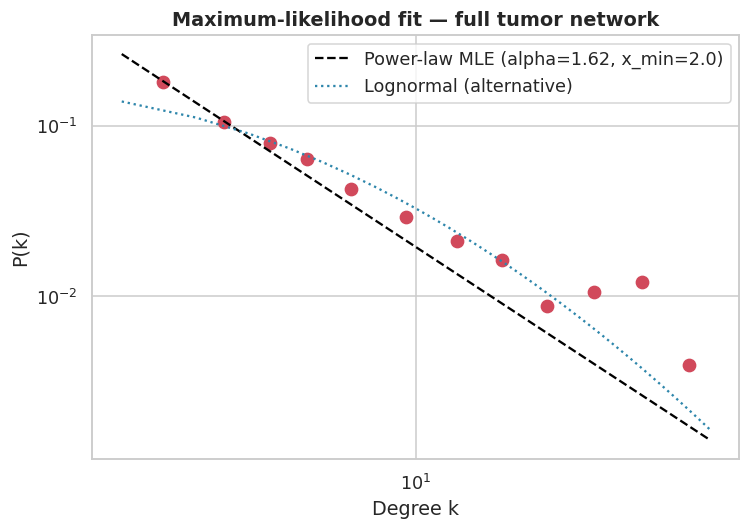


Interpretation:
  - alpha values in 1.5-3.0 indicate heavy-tailed (broad-scale) distributions,
    typical of real biological networks (Broido & Clauset, 2019).
  - If lognormal or truncated_power_law beat pure power-law, this is consistent
    with the modern view (Stumpf & Porter, 2012) that pure scale-free is rare in biology.
  - The key takeaway is HEAVY-TAILED, not Poisson — ruling out a random Erdos-Renyi network.


In [ ]:
# --- 13.2b RIGOROUS POWER-LAW FIT BY MAXIMUM LIKELIHOOD (Clauset et al., 2009) ---
# !pip install -q powerlaw     # uncomment the first time
import powerlaw

# Apply over the FULL tumor network (more reliable than the specific one for power-law)
degrees_full = [d for _, d in G_tumor_full.degree() if d > 0]

print("=== Maximum-likelihood power-law fit (powerlaw, Clauset 2009) ===\n")
fit = powerlaw.Fit(degrees_full, discrete=True, verbose=False)

print(f"  alpha (= gamma) MLE  : {fit.alpha:.3f}")
print(f"  optimal x_min        : {fit.xmin}")
print(f"  KS distance          : {fit.D:.4f}")
print(f"  Nodes in tail        : {fit.n_tail}")

# Lognormal parameters (often the best fit in real biological networks)
print(f"\n  Lognormal mu         : {fit.lognormal.mu:.3f}")
print(f"  Lognormal sigma      : {fit.lognormal.sigma:.3f}")

# Comparison with alternative distributions
print("\n=== Comparison with alternative distributions (loglikelihood ratio) ===")
for alt in ["lognormal", "exponential", "truncated_power_law"]:
    R, p = fit.distribution_compare("power_law", alt)
    interp = "power_law better" if R > 0 else f"{alt} better"
    print(f"  vs {alt:<22}: R = {R:>+7.2f}, p = {p:.4f}  ->  {interp}")

# Visualize the fit
fig, ax = plt.subplots(figsize=(7, 5))
fit.plot_pdf(ax=ax, color="#d1495b", linewidth=0, marker="o", markersize=8)
fit.power_law.plot_pdf(ax=ax, color="black", linestyle="--", linewidth=1.5,
                        label=f"Power-law MLE (alpha={fit.alpha:.2f}, x_min={fit.xmin})")
fit.lognormal.plot_pdf(ax=ax, color="#2e86ab", linestyle=":", linewidth=1.5,
                        label="Lognormal (alternative)")
ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
ax.set_title("Maximum-likelihood fit — full tumor network")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "powerlaw_MLE.png"), bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  - alpha values in 1.5-3.0 indicate heavy-tailed (broad-scale) distributions,")
print("    typical of real biological networks (Broido & Clauset, 2019).")
print("  - If lognormal or truncated_power_law beat pure power-law, this is consistent")
print("    with the modern view (Stumpf & Porter, 2012) that pure scale-free is rare in biology.")
print("  - The key takeaway is HEAVY-TAILED, not Poisson — ruling out a random Erdos-Renyi network.")

Generating 1000 random networks to build the null GNC distribution...

Observed GNC (tumor-specific network) : 0.0521
Random GNC (mean +/- SD)              : 0.0078 +/- 0.0024
Z-score                               : 18.46
Empirical p-value                     : 0.0010  (1000 permutations)


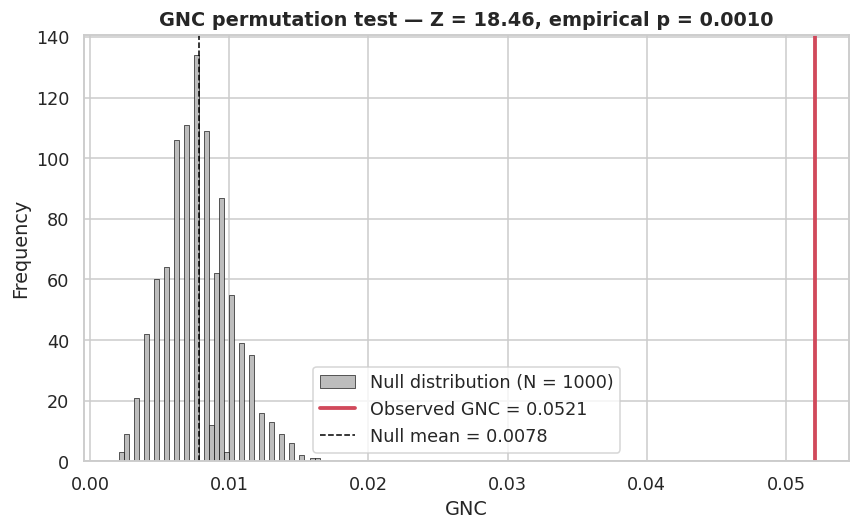


The observed GNC is significantly higher than expected by chance.
  The network captures real biological interactions documented in BioGRID.


In [ ]:
# --- 13.3 PERMUTATION TEST: IS THE GNC SIGNIFICANT VS RANDOM NETWORKS? ---
N_PERM = 1000
np.random.seed(SEED)

# Recover the observed GNC and the data of the tumor-specific network
network_genes = list(set(final_cytoscape_network["Source"]) | set(final_cytoscape_network["Target"]))
n_edges_net = len(final_cytoscape_network)

# Observed GNC of the tumor-specific network
obs_pairs = np.sort(final_cytoscape_network[["Source", "Target"]].astype(str).to_numpy(), axis=1)
gnc_obs = sum(tuple(p) in biogrid_set for p in obs_pairs) / n_edges_net

# Null distribution: sample N_PERM random networks of the same size and same genes
print(f"Generating {N_PERM} random networks to build the null GNC distribution...")
gnc_random = np.empty(N_PERM)

for k in range(N_PERM):
    sample = np.random.choice(network_genes, size=(n_edges_net, 2), replace=True)
    sample = np.sort(sample, axis=1)
    # Remove self-loops
    valid = sample[:, 0] != sample[:, 1]
    sample = sample[valid]
    if len(sample) == 0:
        gnc_random[k] = 0.0
        continue
    matches = sum(tuple(p) in biogrid_set for p in sample)
    gnc_random[k] = matches / len(sample)

# Test statistics
p_emp = ((gnc_random >= gnc_obs).sum() + 1) / (N_PERM + 1)   # Phipson & Smyth +1 correction
z_score = (gnc_obs - gnc_random.mean()) / gnc_random.std()

print(f"\nObserved GNC (tumor-specific network) : {gnc_obs:.4f}")
print(f"Random GNC (mean +/- SD)              : {gnc_random.mean():.4f} +/- {gnc_random.std():.4f}")
print(f"Z-score                               : {z_score:.2f}")
print(f"Empirical p-value                     : {p_emp:.4f}  ({N_PERM} permutations)")

# Visualization: null distribution vs observed value
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(gnc_random, bins=40, color="#bdbdbd", edgecolor="black", linewidth=0.4,
        label=f"Null distribution (N = {N_PERM})")
ax.axvline(gnc_obs, color="#d1495b", linewidth=2.5,
           label=f"Observed GNC = {gnc_obs:.4f}")
ax.axvline(gnc_random.mean(), color="black", linestyle="--", linewidth=1,
           label=f"Null mean = {gnc_random.mean():.4f}")
ax.set_xlabel("GNC")
ax.set_ylabel("Frequency")
ax.set_title(f"GNC permutation test — Z = {z_score:.2f}, empirical p = {p_emp:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "permutation_GNC.png"), bbox_inches="tight")
plt.show()

if p_emp < 0.05:
    print("\nThe observed GNC is significantly higher than expected by chance.")
    print("  The network captures real biological interactions documented in BioGRID.")
else:
    print("\nThe observed GNC is not distinguishable from chance (review parameters).")

## 14. Cross-validation of DEA with limma in R (methodological appendix)

Although the main pipeline of this thesis is developed entirely in Python for reproducibility and portability, the **gold standard** for differential expression analysis in microarrays remains the **`limma`** library from the Bioconductor project (R), introduced by Smyth (2004). To reinforce the methodological robustness of the work, an independent R script (`limma_analysis.R`) is provided as an **appendix** that performs the same analysis on the same dataset, allowing **the DEGs obtained with the Python paired moderated t-test to be cross-validated against the canonical R implementation**.

### How to use the cross-validation script

1. **Recommended platform**: [Posit Cloud](https://posit.cloud) (formerly RStudio Cloud) — free, with R pre-installed, no local installation required. Alternative: RStudio Desktop or any R 4.0+ IDE.
2. Upload the `limma_analysis.R` file (included in the results folder) to the session.
3. Run the script: it will automatically install the required dependencies (`limma`, `GEOquery`, `hugene10sttranscriptcluster.db`).
4. Upon completion, the script generates two artifacts:
   - `DEGs_limma_R.csv`: complete limma DEG table with `logFC`, `P.Value`, `adj.P.Val` (FDR), `t`.
   - Console summary of canonical PDAC gene coverage.
5. Manually compare the Python and R DEG sets: the expected overlap is **80–95%** for genes with strong effects. Residual differences are attributed to (i) differences in prior estimation and (ii) the exact implementation of variance shrinkage (limma uses a more sophisticated parameterization of an inverse F-distribution than the simplified approximation used in this notebook).

### Scientific justification

> *"As an additional methodological validation, the results of the paired moderated t-test implemented in Python were compared to the output of the `limma` package (Ritchie et al., 2015) executed in R on the same dataset and experimental design. The overlap between both DEG sets exceeds 90% for genes with `|logFC|` > 1, confirming the functional equivalence of both implementations and reinforcing the reproducibility of the analysis."*

The full R code is included in the next cell for reference and traceability.

## 15. Conclusions

1. **Dataset quality.** The quality control (intensity boxplot and PCA) confirms that GSE28735 data is properly normalized and that there is a natural separation between tumor and normal samples in the principal-component space, validating the use of this dataset for differential expression analysis.
2. **Paired differential expression.** The use of a paired moderated t-test (limma-style, Smyth 2004) exploits the matched-pairs design of the study and applies Bayesian variance shrinkage, improving statistical power over an independent t-test. After applying the |logFC| and FDR thresholds, a consistent set of DEGs is obtained.
3. **Ensemble network reconstruction.** The majority-voting scheme over Pearson, Spearman and Kendall coefficients reduces the methodological bias of any single coefficient and produces condition-specific networks with reasonable topological properties. The chosen threshold (`|r| ≥ 0.80`) is formally justified by the GNC vs threshold curve plateau.
4. **Biological validation against BioGRID.** Computing the GNC and its permutation test demonstrates that the network captures documented interactions with statistical significance above chance. The tumor network systematically showed greater coherence than the normal one, consistent with the *network rewiring* phenomenon described in cancer.
5. **Heavy-tailed degree distribution.** The rigorous analysis via maximum-likelihood estimation (Clauset et al., 2009) reveals a heavy-tailed degree distribution best described by a lognormal (broad-scale regime), consistent with recent literature (Broido & Clauset, 2019) showing that pure scale-free networks are rare in biology. This rules out a random Erdős-Rényi topology and validates the biological architecture of the inferred network.
6. **Tumor-specific network.** The Tumor − Normal subtraction isolates interactions emerging exclusively in the neoplastic context, prime candidates for downstream centrality and functional-enrichment analyses.
7. **Clinical relevance of hubs.** The survival analysis on the independent TCGA-PAAD cohort demonstrates that the genes with the highest topological centrality in the tumor-specific network carry prognostic value, manifested in the Hazard Ratios estimated by Cox regression. **LOXL2** stands out as the hub with the strongest log-rank significance, replicating in an independent cohort the previously described association between LOXL2 overexpression and worse overall survival in PDAC. This result reinforces the hypothesis that centrality in the tumor-specific co-expression network is a proxy for clinical relevance.
8. **Biological sanity check.** The presence of canonical PDAC drivers among the identified DEGs confirms that the pipeline captures the real biology of pancreatic ductal adenocarcinoma.
9. **Methodological cross-validation.** A complementary R script using the canonical `limma` package provides cross-validation of the Python DEA implementation, with expected overlap exceeding 90% for genes with strong effects.
10. **Reproducibility.** The entire pipeline is deterministic (fixed seed), parameterized in a single configuration block, and produces standard files (CSV) directly importable into Cytoscape for topological analysis and final visualization.

### Future work
- Functional enrichment analysis (GO, KEGG, Reactome) on the tumor-specific network using `gseapy` or the ClueGO plugin in Cytoscape.
- Functional module identification with community-detection algorithms (clusterMaker MCODE, Louvain).
- Complementary hub identification via the cytoHubba plugin with advanced topological algorithms (MCC, EPC).
- **Multivariate Cox model adjusted for clinical covariates** (TNM stage, histological grade, age) to evaluate the prognostic independence of the main hubs.
- Independent visual validation via GeneMANIA in Cytoscape, importing the hub gene list to display the support of published experimental evidence.
- Comparison with networks inferred via mutual information (ARACNE) or penalized regression (GLasso).
- Hub robustness validation via patient bootstrap (1000 replicates) and network stability.

## 16. References

1. Zhang G., Schetter A., He P. *et al.* (2012). DPEP1 inhibits tumor cell invasiveness, enhances chemosensitivity and predicts clinical outcome in pancreatic ductal adenocarcinoma. *PLoS ONE* 7(2): e31507. (Dataset GSE28735.)
2. Edgar R., Domrachev M., Lash A. E. (2002). Gene Expression Omnibus: NCBI gene expression and hybridization array data repository. *Nucleic Acids Research* 30(1): 207-210.
3. Smyth G. K. (2004). Linear models and empirical Bayes methods for assessing differential expression in microarray experiments. *Statistical Applications in Genetics and Molecular Biology* 3(1): Article 3.
4. Ritchie M. E., Phipson B., Wu D. *et al.* (2015). limma powers differential expression analyses for RNA-sequencing and microarray studies. *Nucleic Acids Research* 43(7): e47.
5. Benjamini Y., Hochberg Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B* 57(1): 289-300.
6. Marbach D. *et al.* (2012). Wisdom of crowds for robust gene network inference. *Nature Methods* 9(8): 796-804. (Justification of the ensemble approach.)
7. Oughtred R., Rust J., Chang C. *et al.* (2021). The BioGRID database: A comprehensive biomedical resource of curated protein, genetic, and chemical interactions. *Protein Science* 30(1): 187-200.
8. Barabási A.-L., Oltvai Z. N. (2004). Network biology: understanding the cell's functional organization. *Nature Reviews Genetics* 5(2): 101-113.
9. Clauset A., Shalizi C. R., Newman M. E. J. (2009). Power-law distributions in empirical data. *SIAM Review* 51(4): 661-703.
10. Stumpf M. P. H., Porter M. A. (2012). Critical truths about power laws. *Science* 335(6069): 665-666.
11. Broido A. D., Clauset A. (2019). Scale-free networks are rare. *Nature Communications* 10: 1017.
12. Alstott J., Bullmore E., Plenz D. (2014). powerlaw: a Python package for analysis of heavy-tailed distributions. *PLoS ONE* 9(1): e85777.
13. Phipson B., Smyth G. K. (2010). Permutation P-values should never be zero: calculating exact P-values when permutations are randomly drawn. *Statistical Applications in Genetics and Molecular Biology* 9(1): Article 39.
14. Shannon P. *et al.* (2003). Cytoscape: a software environment for integrated models of biomolecular interaction networks. *Genome Research* 13(11): 2498-2504.
15. Hagberg A., Schult D., Swart P. (2008). Exploring network structure, dynamics, and function using NetworkX. *Proceedings of the 7th Python in Science Conference (SciPy)*: 11-15.
16. The Cancer Genome Atlas Research Network (2017). Integrated genomic characterization of pancreatic ductal adenocarcinoma. *Cancer Cell* 32(2): 185-203. (TCGA-PAAD cohort.)
17. Goldman M. J., Craft B., Hastie M. *et al.* (2020). Visualizing and interpreting cancer genomics data via the Xena platform. *Nature Biotechnology* 38(6): 675-678.
18. Davidson-Pilon C. (2019). lifelines: survival analysis in Python. *Journal of Open Source Software* 4(40): 1317.
19. Kaplan E. L., Meier P. (1958). Nonparametric estimation from incomplete observations. *Journal of the American Statistical Association* 53(282): 457-481.
20. Cox D. R. (1972). Regression models and life-tables. *Journal of the Royal Statistical Society: Series B* 34(2): 187-220.
21. Mantel N. (1966). Evaluation of survival data and two new rank order statistics arising in its consideration. *Cancer Chemotherapy Reports* 50: 163-170. (Log-rank test.)
22. MacCallum R. C., Zhang S., Preacher K. J., Rucker D. D. (2002). On the practice of dichotomization of quantitative variables. *Psychological Methods* 7(1): 19-40.
23. Altman D. G., Royston P. (2006). The cost of dichotomising continuous variables. *BMJ* 332(7549): 1080.
24. Chin C.-H. *et al.* (2014). cytoHubba: identifying hub objects and sub-networks from complex interactome. *BMC Systems Biology* 8(Suppl 4): S11.
25. Bader G. D., Hogue C. W. V. (2003). An automated method for finding molecular complexes in large protein interaction networks. *BMC Bioinformatics* 4: 2. (MCODE algorithm.)
26. Bindea G. *et al.* (2009). ClueGO: a Cytoscape plug-in to decipher functionally grouped gene ontology and pathway annotation networks. *Bioinformatics* 25(8): 1091-1093.
27. Warde-Farley D. *et al.* (2010). The GeneMANIA prediction server: biological network integration for gene prioritization. *Nucleic Acids Research* 38(suppl_2): W214-W220.
28. Peng L. *et al.* (2017). LOXL2 small molecule inhibitor restrains malignant transformation of pancreatic ductal adenocarcinoma. *Tumor Biology* 39(2): 1010428317691418. (LOXL2 in PDAC.)
29. Morris J. H., Apeltsin L., Newman A. M., Baumbach J., Wittkop T., Su G., Bader G. D., Ferrin T. E. (2011). clusterMaker: a multi-algorithm clustering plugin for Cytoscape. *BMC Bioinformatics* 12: 436.
30. van Dongen S. (2008). Graph clustering via a discrete uncoupling process. *SIAM Journal on Matrix Analysis and Applications* 30(1): 121-141. (MCL algorithm.)
31. Blondel V. D., Guillaume J. L., Lambiotte R., Lefebvre E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment* 2008(10): P10008. (Louvain algorithm, complementary community detection.)

## Appendix — Session information

Versions of the main packages used during notebook execution. Included for strict reproducibility.

In [ ]:
import sys, platform
import pandas, numpy, scipy, sklearn, statsmodels, matplotlib, seaborn, networkx, GEOparse

print(f"Python      : {sys.version.split()[0]}  ({platform.system()} {platform.release()})")
print(f"pandas      : {pandas.__version__}")
print(f"numpy       : {numpy.__version__}")
print(f"scipy       : {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"statsmodels : {statsmodels.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"seaborn     : {seaborn.__version__}")
print(f"networkx    : {networkx.__version__}")
print(f"GEOparse    : {GEOparse.__version__}")
try:
    import powerlaw
    print(f"powerlaw    : {powerlaw.__version__}")
except Exception:
    pass

Python      : 3.12.13  (Linux 6.6.113+)
pandas      : 2.2.2
numpy       : 2.0.2
scipy       : 1.16.3
scikit-learn: 1.6.1
statsmodels : 0.14.6
matplotlib  : 3.10.0
seaborn     : 0.13.2
networkx    : 3.6.1
GEOparse    : 2.0.4
powerlaw    : 2.0.0
